# Descriptive statistics - Topic 03: Variability

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%202%20-%20Unit%20Objective.png"> 

## Topic Objectives

* Interpret the concepts concerning descriptive statistics


---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%204%20-%20Import%20Package%20for%20Learning.png"> 

## Import Packages for Learning

In [1]:
import numpy as np
import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

## Variability

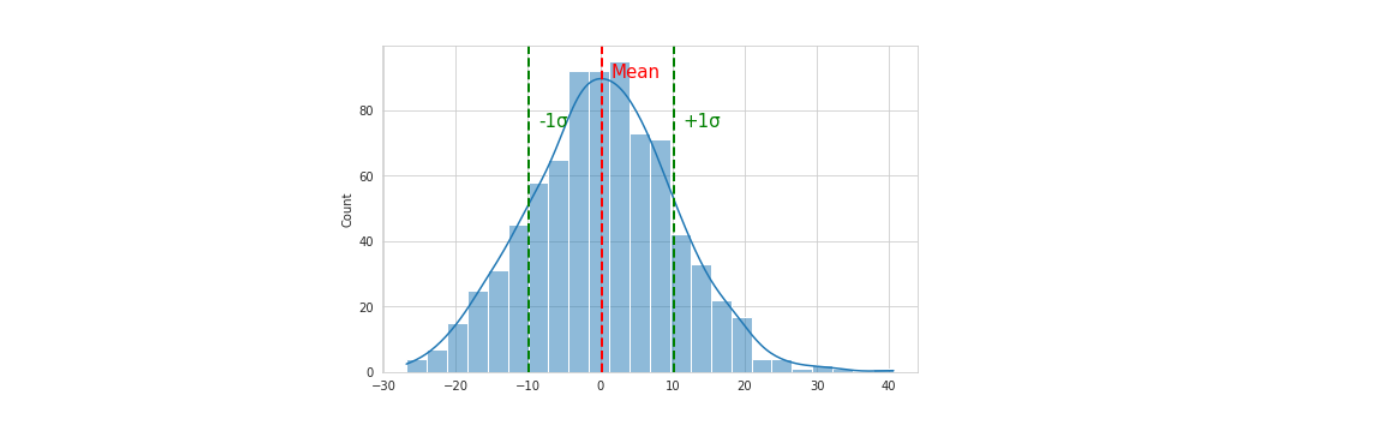

Let's load the DataFrame df we used in the previous unit

In [2]:
from scipy.stats import skewnorm
np.random.seed(seed=1)
size=800

X1 = np.random.normal(loc=40, scale=2, size=int(size/2) )
X2 = np.random.normal(loc=10, scale=4, size=int(size/2) ) 
bi_modal = np.concatenate([X1, X2])

X1 = np.random.normal(loc=40, scale=4, size=int(size/4) )
X2 = np.random.normal(loc=10, scale=4, size=int(size/4) ) 
X3 = np.random.normal(loc=0, scale=2, size=int(size/4) ) 
X4 = np.random.normal(loc=80, scale=2, size=int(size/4) ) 
multi_modal = np.concatenate([X1, X2, X3, X4])


df = pd.DataFrame(data={'Normal':np.random.normal(loc=0, scale=2, size=size),
                        "Positive Skewed": skewnorm.rvs(a=10, size=size),
                        "Negative Skewed": skewnorm.rvs(a=-10, size=size),
                        "Exponential":np.random.exponential(scale=20,size=size),
                        "Uniform":np.random.uniform(low=0.0, high=1.0, size=size),
                        "Bimodal":  bi_modal,
                        "Multimodal":  multi_modal,
                        "Poisson":np.random.poisson(lam=1.0, size=size),
                        "Discrete": np.random.choice([10,12,14,15,16,17,20],size=size),
                        }).round(3)

df.head(3)

,Normal,Positive Skewed,Negative Skewed,Exponential,Uniform,Bimodal,Multimodal,Poisson,Discrete
0,0.582,0.340,-0.069,53.617,0.124,43.249,43.257,3,15
1,2.150,1.181,-0.127,1.214,0.667,38.776,43.122,0,16
2,-1.396,1.592,-0.288,4.921,0.014,38.944,34.144,0,10


We are adding more columns to our DataFrame. They are normal distributions with different standard deviations: 1, 5 and 10. They were generated with `np.random.normal()`, and its documentation is [here](https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html).
* These new variables will help to illustrate better the concepts covered in this unit

In [3]:
df['NormalStd_1']= np.random.normal(loc=0, scale=1, size=size)
df['NormalStd_5']= np.random.normal(loc=0, scale=5, size=size)
df['NormalStd_10']= np.random.normal(loc=0, scale=10, size=size)

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Measures of Variability. 
* We are interested in complementing the previous analysis with more information **by quantifying how the data is spread** by calculating:
    * Variance
    * Standard Deviation
    * Skewness
    * Kurtosis
    * Percentiles and Quartiles
    * Range


---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Variance

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Variance shows the spread of the data around the mean; it is a number that **tells how far/close the data points are from the mean**
  * To calculate the variance from your numerical data in your DataFrame or Series, use the method **.var()**
  * Pandas by default calculates a sample variance as opposed to the population variance. Sample variance is more commonly used as you rarely have every value for a whole population. 


$$s_{p}^2 = \frac {(n_{1} - 1)s_{1}^2 + (n_{2} - 1)s_{2}^2}{n_{1} + n_{2} - 2}$$

In [4]:
df.var()

Normal               4.137334
Positive Skewed      0.339450
Negative Skewed      0.403699
Exponential        366.345112
Uniform              0.085860
Bimodal            236.540089
Multimodal         979.336972
Poisson              1.047295
Discrete             9.293678
NormalStd_1          0.983686
NormalStd_5         23.011071
NormalStd_10       100.622525
dtype: float64

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Standard Deviation

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Standard deviation is also related to data spread. It is also known as sigma, and the symbol is **σ**.
  * It measures the **dispersion of the data from the mean** in either direction

* You can calculate the standard deviation from your DataFrame or Series either by applying the square root (using `np.sqrt()`, for example) of variance or using the method `.std()`.  The documentation link is [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.std.html)

In [5]:
np.sqrt(df.var())

Normal              2.034044
Positive Skewed     0.582623
Negative Skewed     0.635373
Exponential        19.140144
Uniform             0.293018
Bimodal            15.379860
Multimodal         31.294360
Poisson             1.023374
Discrete            3.048553
NormalStd_1         0.991809
NormalStd_5         4.796986
NormalStd_10       10.031078
dtype: float64

The most common approach is with `.std()`.

In [6]:
df.std()

Normal              2.034044
Positive Skewed     0.582623
Negative Skewed     0.635373
Exponential        19.140144
Uniform             0.293018
Bimodal            15.379860
Multimodal         31.294360
Poisson             1.023374
Discrete            3.048553
NormalStd_1         0.991809
NormalStd_5         4.796986
NormalStd_10       10.031078
dtype: float64

You can better understand the standard deviation by plotting its value in relation to the mean.
  * In other words, consider your mean, and subtract/add one standard deviation
  * In the cell below, we consider the normal distribution column and plot the mean and one standard deviation in relation to the mean, using what we learned from Matplotlib and Seaborn

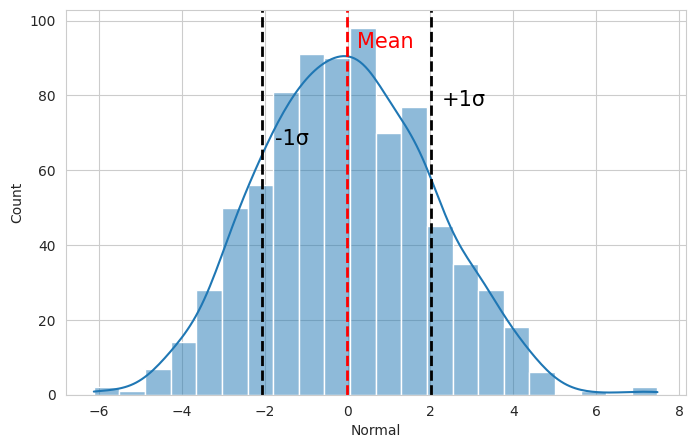

In [7]:
col = 'Normal'

fig, axes = plt.subplots(figsize=(8,5))
sns.histplot(data=df, x=col, kde=True)
plt.axvline(df[col].mean(), color='r', linestyle='dashed', linewidth=2)
plt.text(x=df[col].mean() + df[col].std()/8 , y=axes.get_ylim()[1] * 0.90, s='Mean', fontsize=15, c='r')

plt.axvline(df[col].mean() + df[col].std(), color='k', linestyle='dashed', linewidth=2)
plt.text(x=df[col].mean() + df[col].std() + df[col].std()/8 , y=axes.get_ylim()[1] * 0.75, s='+1σ', fontsize=15, c='k')

plt.axvline(df[col].mean() - df[col].std(), color='k', linestyle='dashed', linewidth=2)
plt.text(x=-df[col].mean() - df[col].std() + df[col].std()/8 , y=axes.get_ylim()[1] * 0.65, s='-1σ', fontsize=15, c='k')

plt.show()

Let's loop over all columns now
* Pay attention to those which extend the data deviation or change around the mean

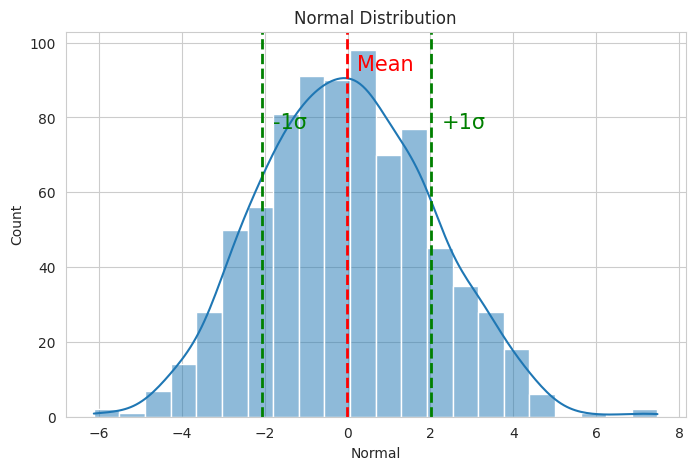

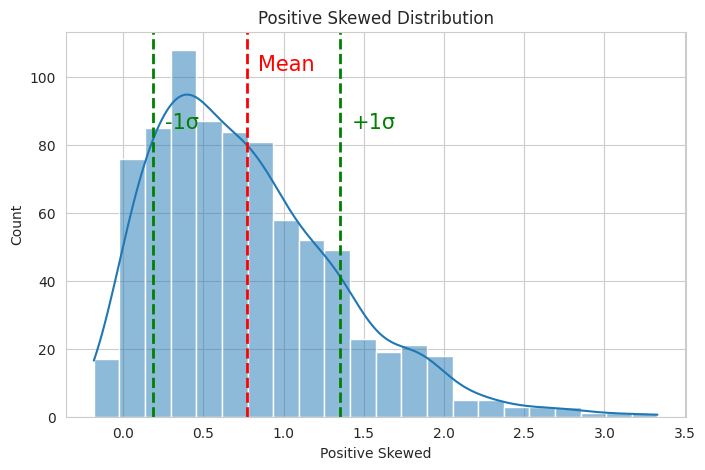

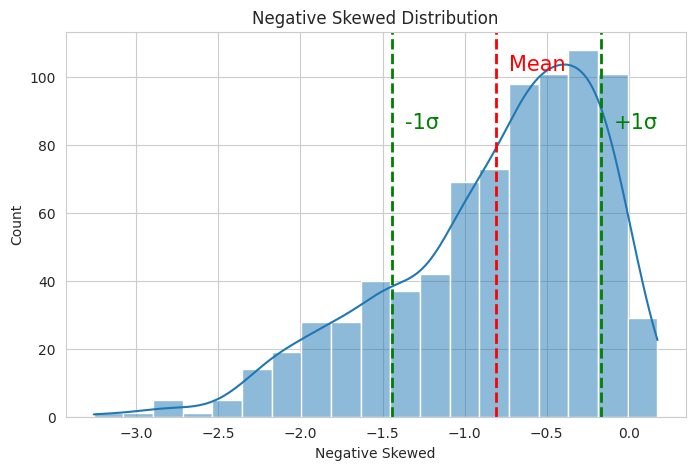

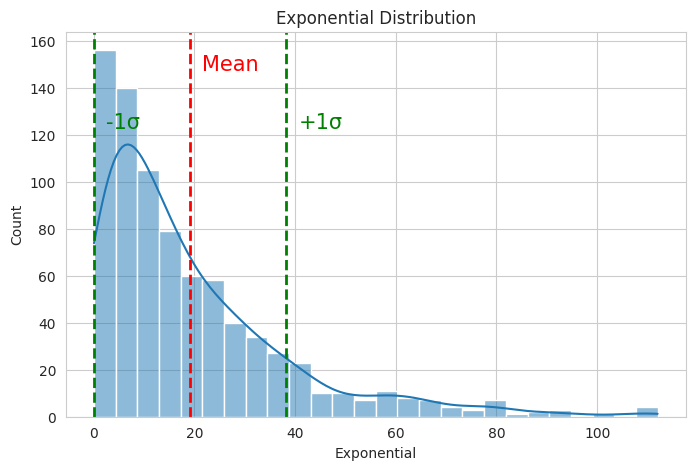

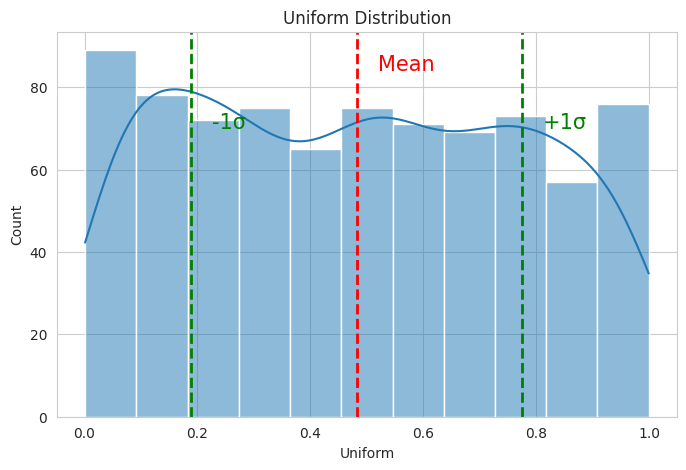

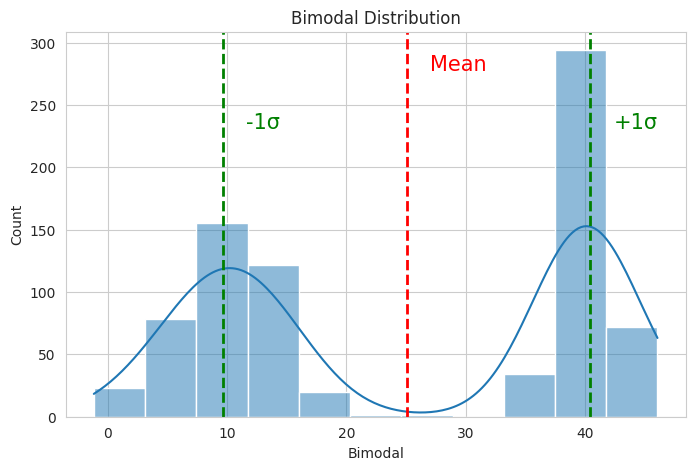

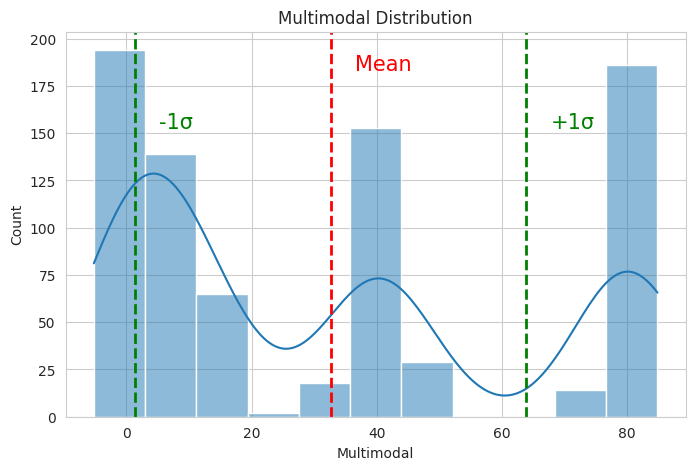

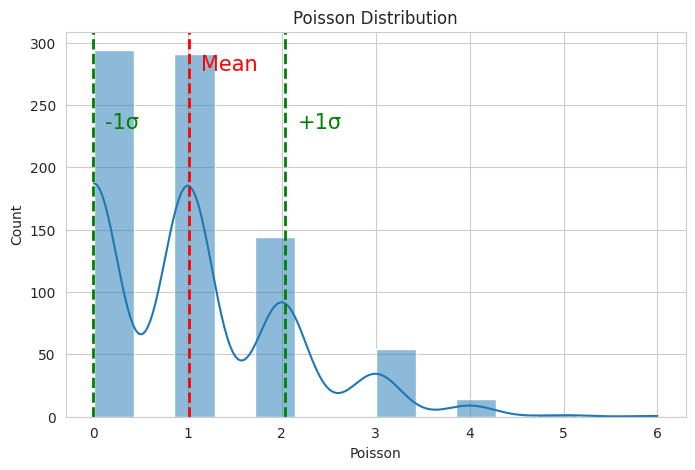

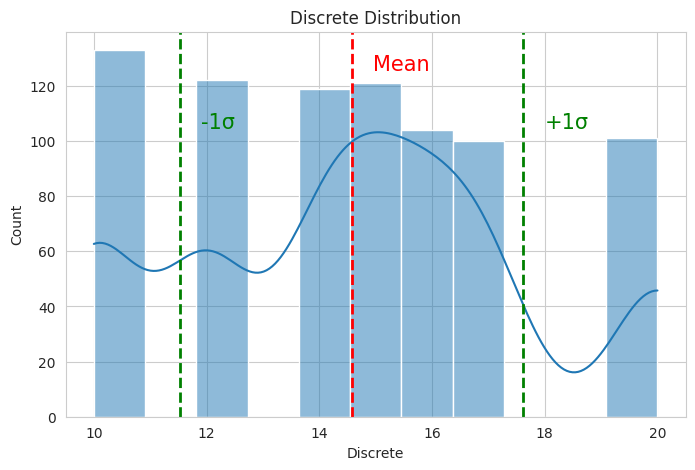

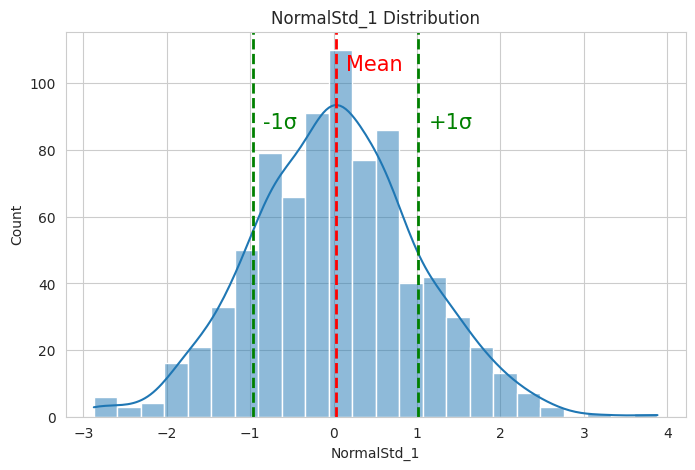

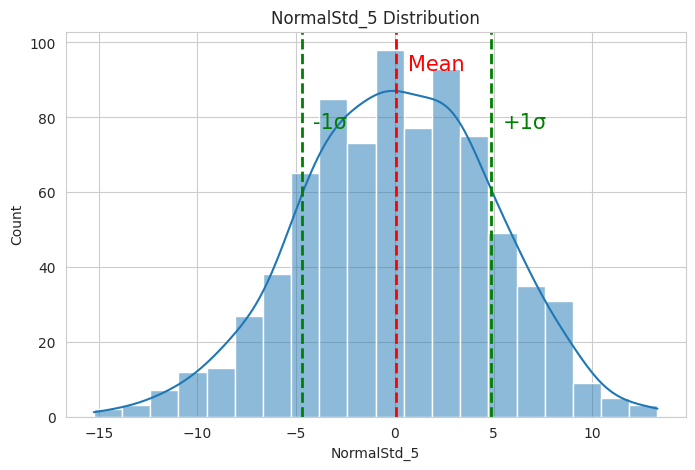

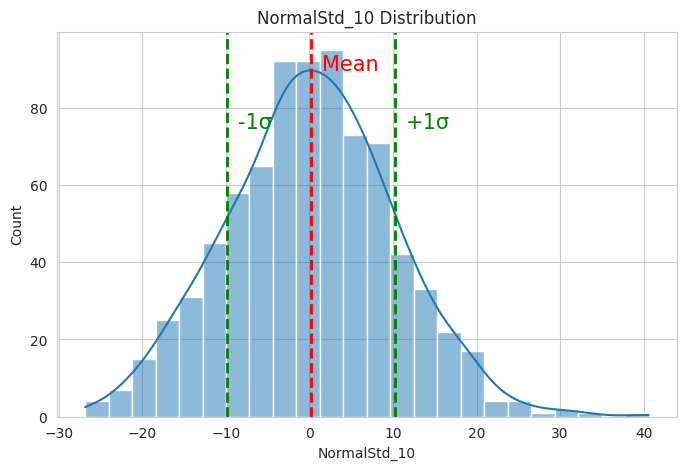

In [8]:
for col in df.columns:

  fig, axes = plt.subplots(figsize=(8,5))
  plt.title(f"{col} Distribution")
  sns.histplot(data=df, x=col, kde=True)
  plt.axvline(df[col].mean(), color='r', linestyle='dashed', linewidth=2)
  plt.text(x=df[col].mean() + df[col].std()/8 , y=axes.get_ylim()[1] * 0.90, s='Mean', fontsize=15, c='r')

  plt.axvline(df[col].mean() + df[col].std(), color='g', linestyle='dashed', linewidth=2)
  plt.text(x=df[col].mean() + df[col].std() + df[col].std()/8 , y=axes.get_ylim()[1] * 0.75, s='+1σ', fontsize=15, c='g')

  plt.axvline(df[col].mean() - df[col].std(), color='g', linestyle='dashed', linewidth=2)
  plt.text(x=df[col].mean() - df[col].std() + df[col].std()/8 , y=axes.get_ylim()[1] * 0.75, s='-1σ', fontsize=15, c='g')

plt.show()


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

There is an empirical rule for a normal distribution that 99.7% (or almost all of the observed data) is within **3 standard deviations** of the mean. 
* Also, 68% of the data falls within one standard deviation and 95% per cent within two standard deviations. Let's check that
* Here, we plot the mean, and three standard deviations from the mean, so we can check if almost all data falls into the interval of 3 standard deviations in a normal distribution

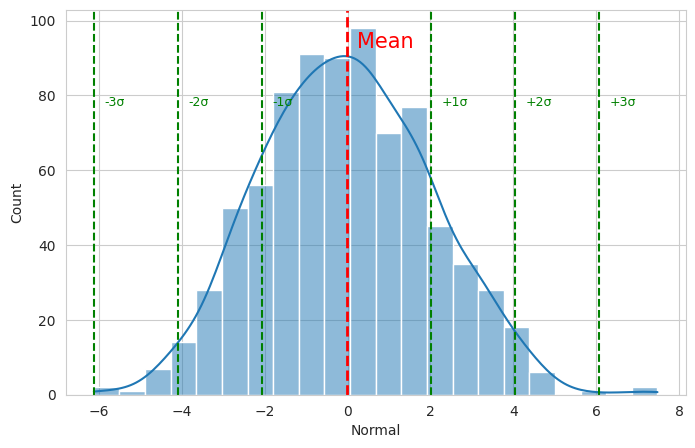

In [9]:
col = 'Normal'

fig, axes = plt.subplots(figsize=(8,5))
sns.histplot(data=df, x=col, kde=True)
plt.axvline(df[col].mean(), color='r', linestyle='dashed', linewidth=2)
plt.text(x=df[col].mean() + df[col].std()/8 , y=axes.get_ylim()[1] * 0.90, s='Mean', fontsize=15, c='r')

for num in[1,2,3]:
  plt.axvline(df[col].mean() + num * df[col].std(), color='g', linestyle='dashed', linewidth=1.5)
  plt.text(x=df[col].mean() + num * df[col].std() + df[col].std()/8 , y=axes.get_ylim()[1] * 0.75, s=f'+{num}σ', fontsize=9, c='g')

  plt.axvline(df[col].mean() - num * df[col].std(), color='g', linestyle='dashed', linewidth=1.5)
  plt.text(x=df[col].mean() - num * df[col].std() + df[col].std()/8 , y=axes.get_ylim()[1] * 0.75, s=f'-{num}σ', fontsize=9, c='g')


plt.show()

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Let's check if this behaviour happens with other types of distributions.
* Note that there are variables where the distribution is inside the positive and negative range of 3 standard deviations; some don't reach two standard deviations of spread.
  * A normal distribution is one where there is symmetrical distribution around the mean. The values less than one standard deviation away from the mean account for 68.27% of the total, while two standard deviations from the mean account for 95.45% and three standard deviations account for 99.73%.
  * This fact makes standard deviation a useful diagnostic. If 1 in every 100 measurements is outside three sigmas, there is no problem. You have an issue if two or more are outside three sigmas. Something has changed in the distribution.


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

At the same time, there are variables, like log-normal, where its values go much further than three standard deviations of spread

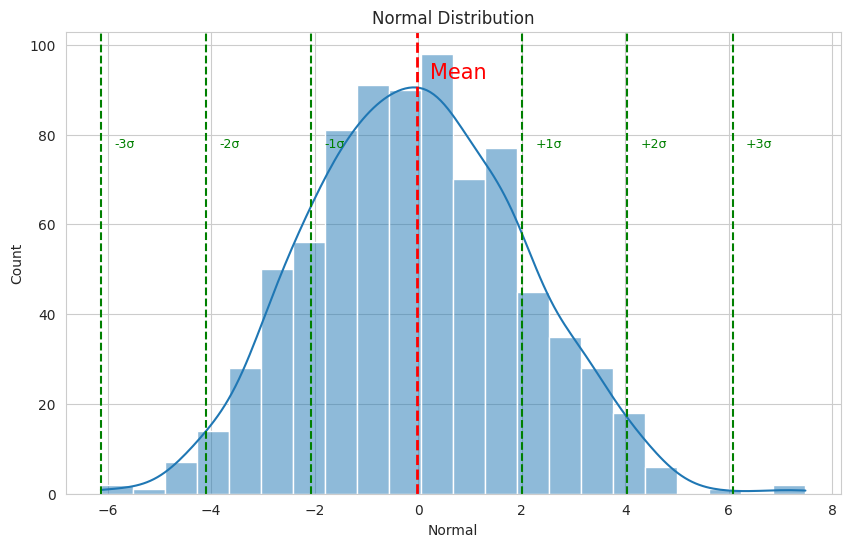

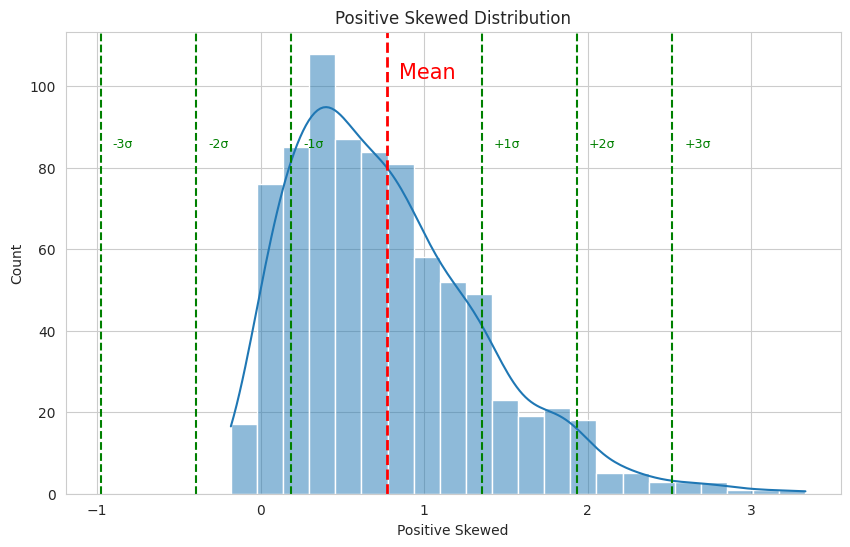

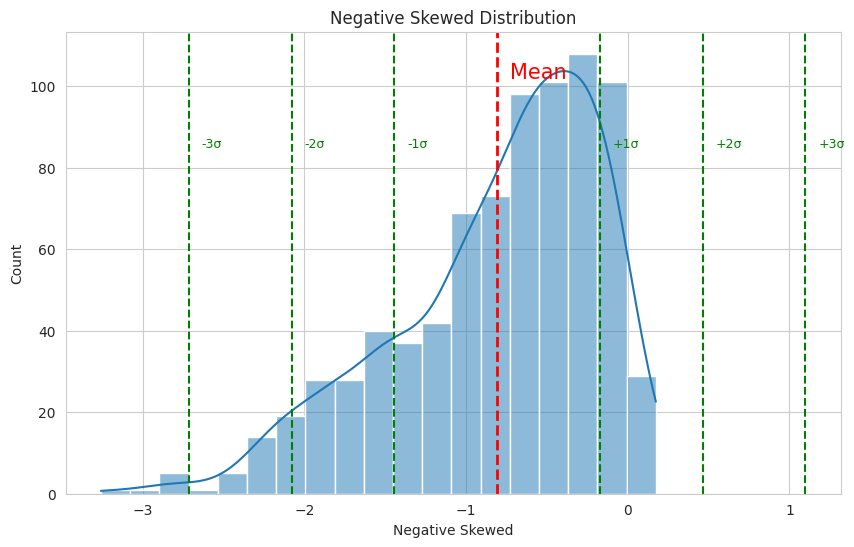

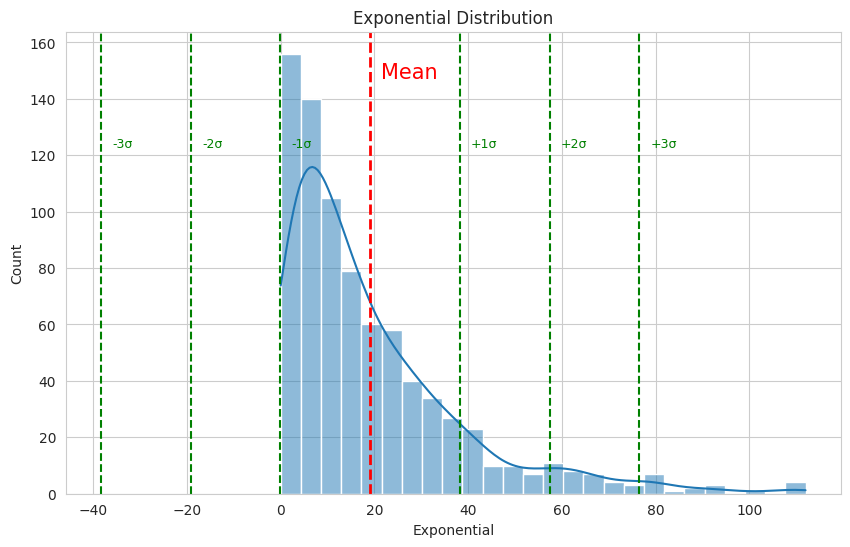

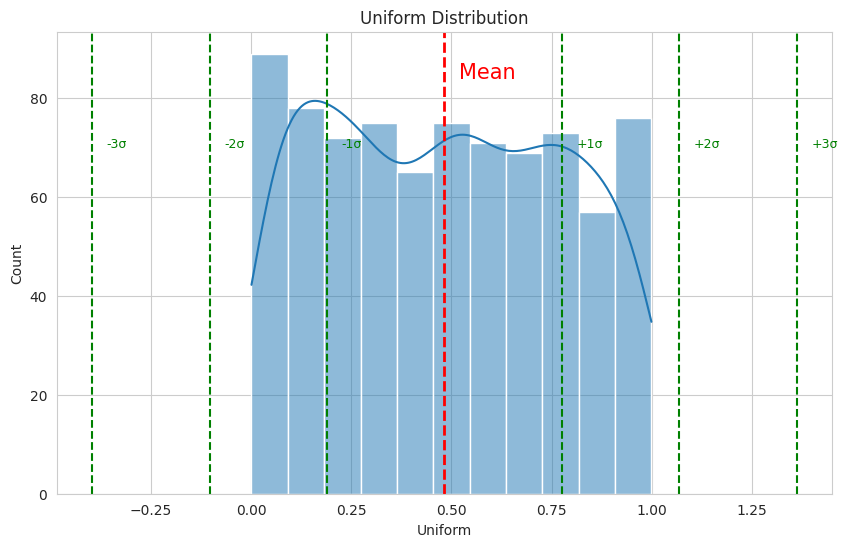

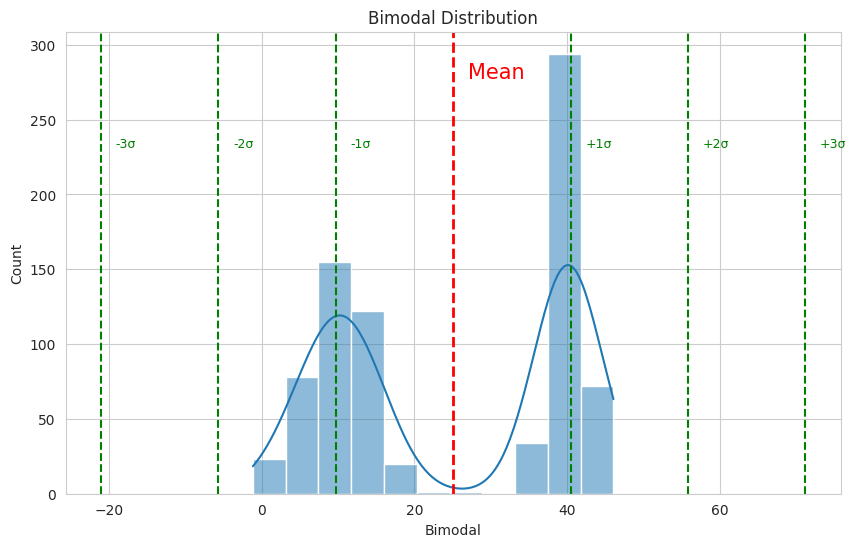

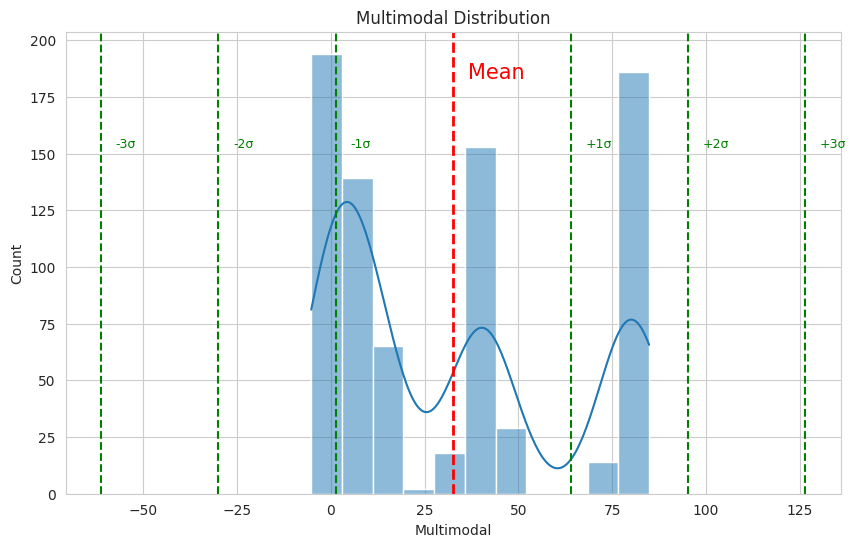

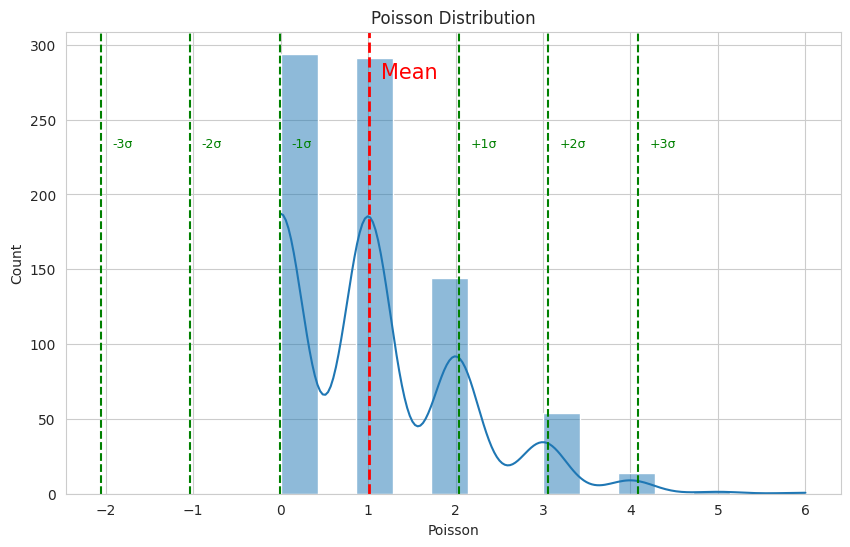

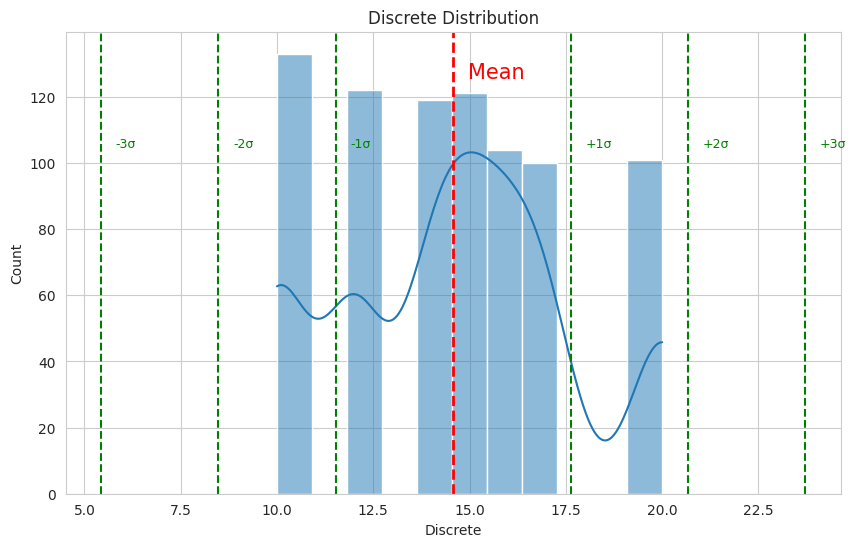

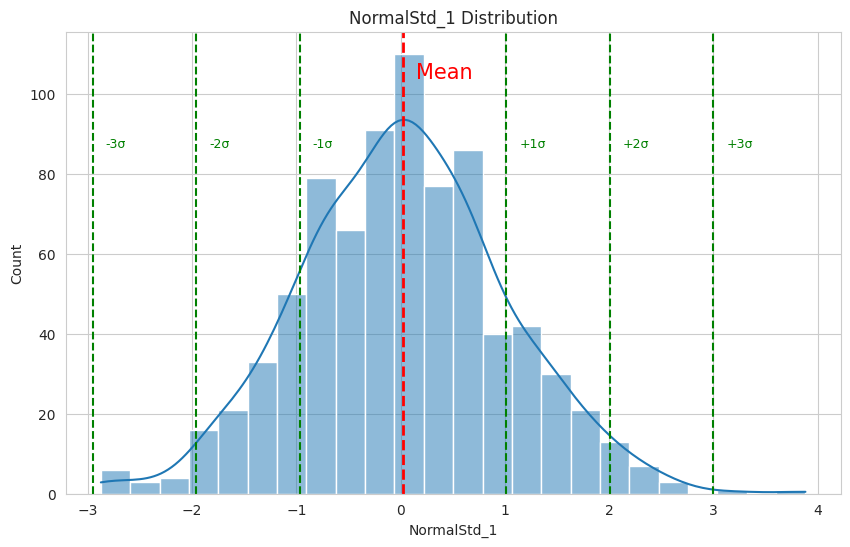

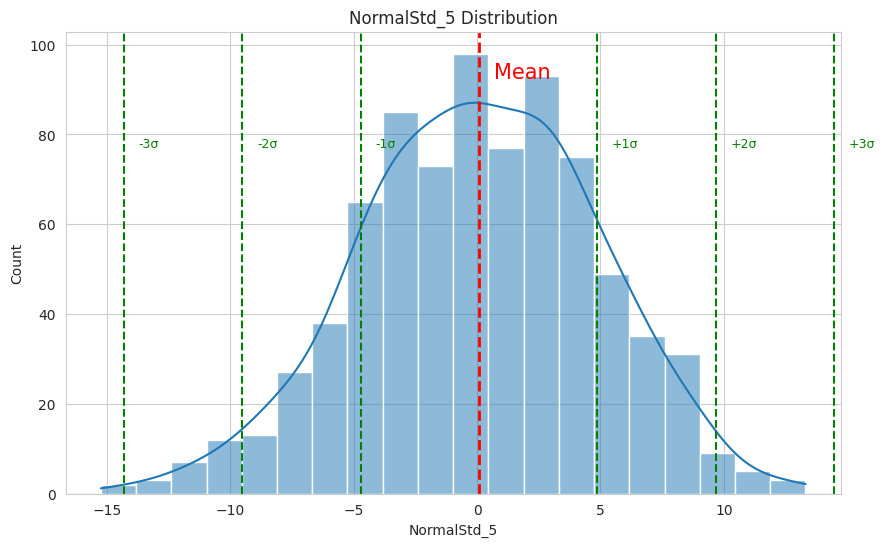

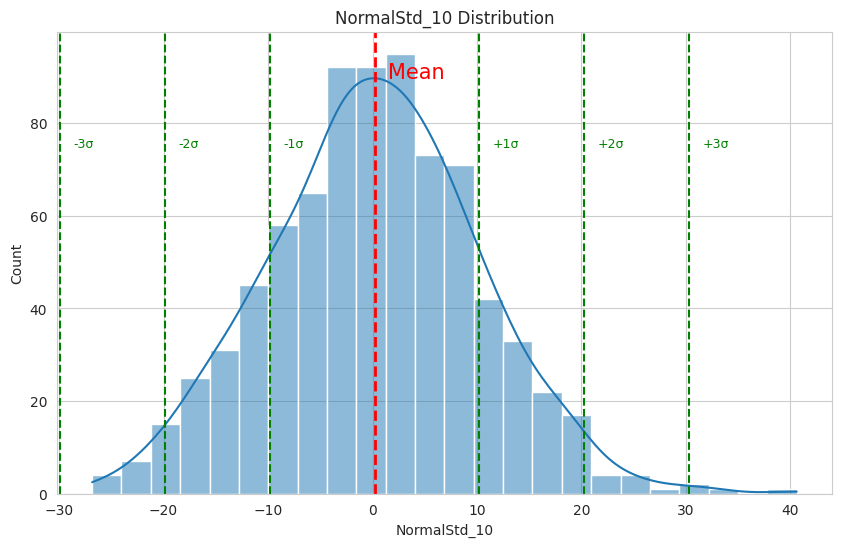

In [10]:
for col in df.columns:

  fig, axes = plt.subplots(figsize=(10,6))
  sns.histplot(data=df, x=col, kde=True)
  plt.title(f"{col} Distribution")
  plt.axvline(df[col].mean(), color='r', linestyle='dashed', linewidth=2)
  plt.text(x=df[col].mean() + df[col].std()/8 , y=axes.get_ylim()[1] * 0.90, s='Mean', fontsize=15, c='r')

  for num in[1,2,3]:
    plt.axvline(df[col].mean() + num * df[col].std(), color='g', linestyle='dashed', linewidth=1.5)
    plt.text(x=df[col].mean() + num * df[col].std() + df[col].std()/8 , y=axes.get_ylim()[1] * 0.75, s=f'+{num}σ', fontsize=9, c='g')

    plt.axvline(df[col].mean() - num * df[col].std(), color='g', linestyle='dashed', linewidth=1.5)
    plt.text(x=df[col].mean() - num * df[col].std() + df[col].std()/8 , y=axes.get_ylim()[1] * 0.75, s=f'-{num}σ', fontsize=9, c='g')


  plt.show()
  print("\n")

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

**Quick QUIZ**
* If you were a machine, **which type of distribution would you ideally like to work on?** Which is more friendly so far?
  * We hope you would say the **normal distribution** since we can easily explain all points using mean and standard deviation
  * **Other distributions** can also be explained; however, a normal distribution is easiest.

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Skewness

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Skewness is the asymmetry of the data. 
  * Distribution is symmetric when it looks the same to the left and right of the centre point. It is mirrored.
    * The closer to zero, the less skewed the data is, and the more symmetrical the data is.
    * Positive Skewness happens when the tail on the right side is longer. 
    * Negative Skewness happens when the tail of the left side of the distribution is longer.

* If, for example, your values are all positive but are close to zero, then your distribution will be skewed as you cannot have negative values. This is considered a distribution bound by 0. This equally applies to any hard boundary for your value

* To calculate skewness in your DataFrame or Series, use `.skew()`. The documentation is [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.skew.html)

In [11]:
df.skew()

Normal             0.143826
Positive Skewed    0.984182
Negative Skewed   -0.891811
Exponential        1.863707
Uniform            0.067813
Bimodal           -0.080381
Multimodal         0.500373
Poisson            1.021067
Discrete           0.135004
NormalStd_1        0.073531
NormalStd_5       -0.127582
NormalStd_10       0.114864
dtype: float64

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Can you correlate the skew levels and the distribution shape?
  * You will notice that positive or negative skewness levels above 2 create a significant asymmetry in your data. Check the Exponential column

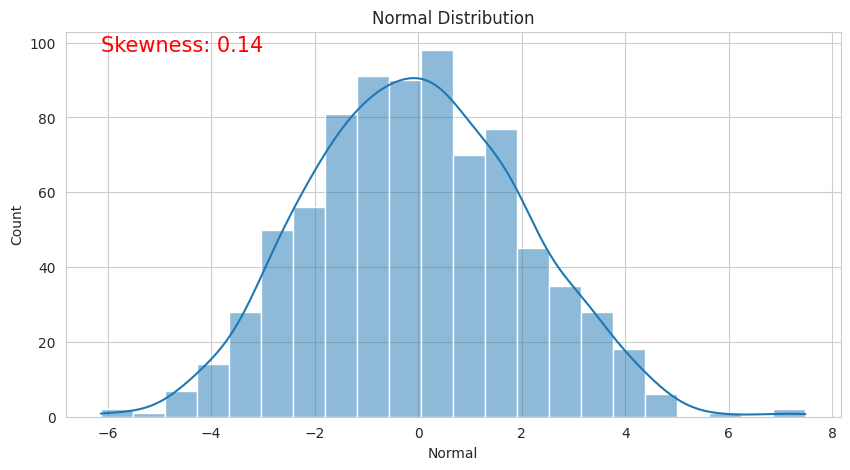

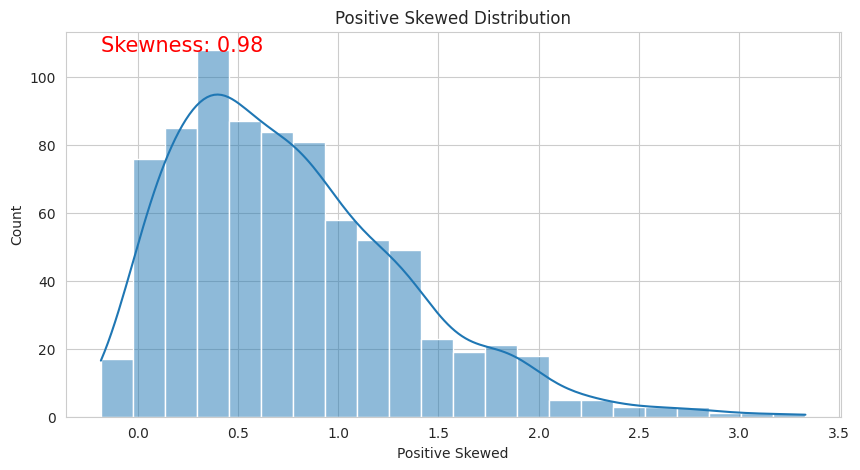

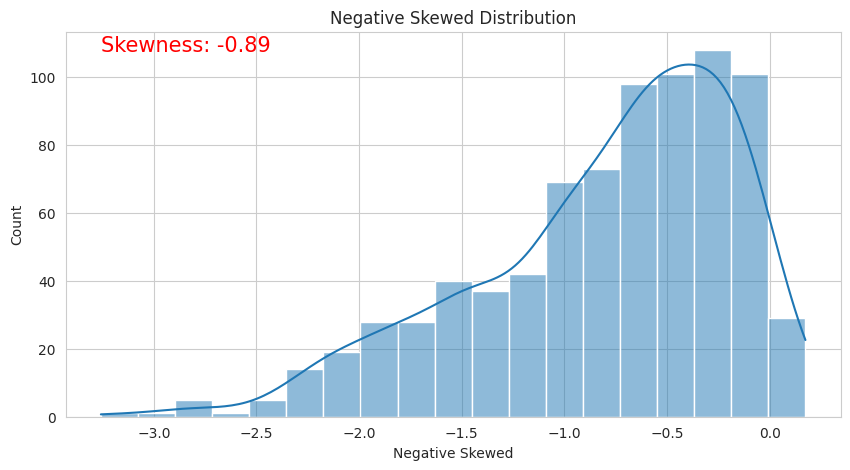

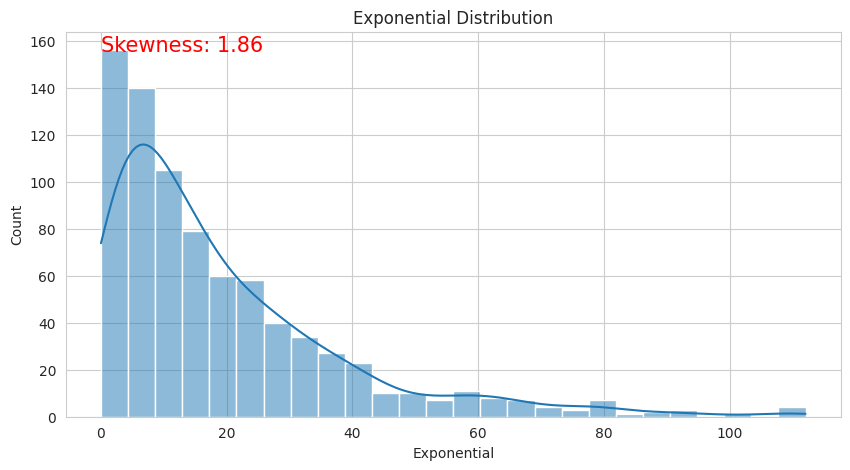

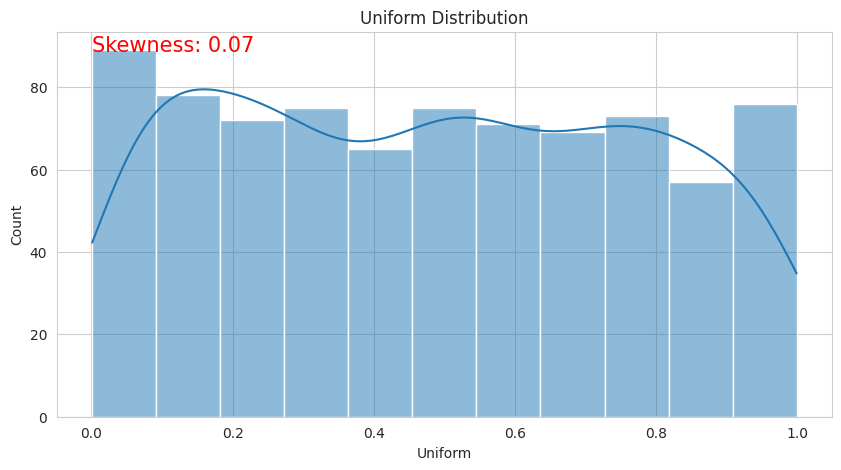

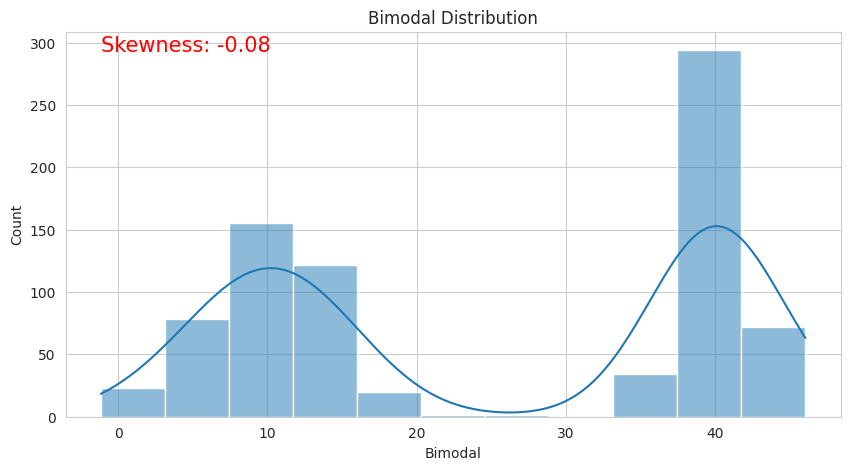

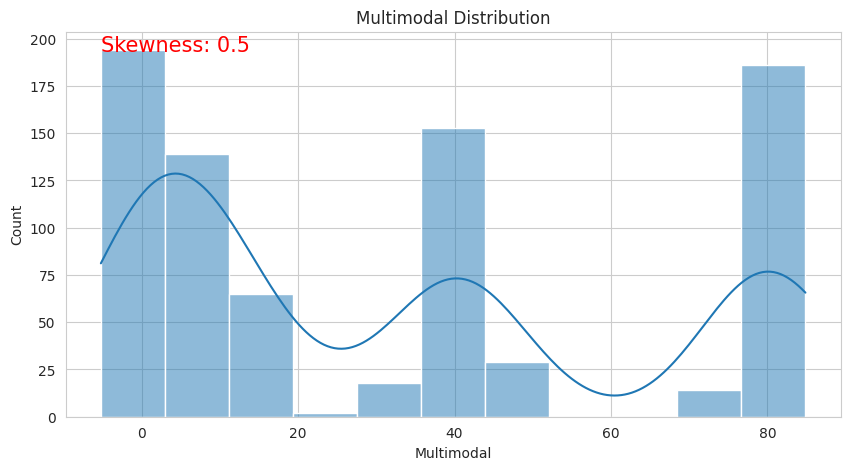

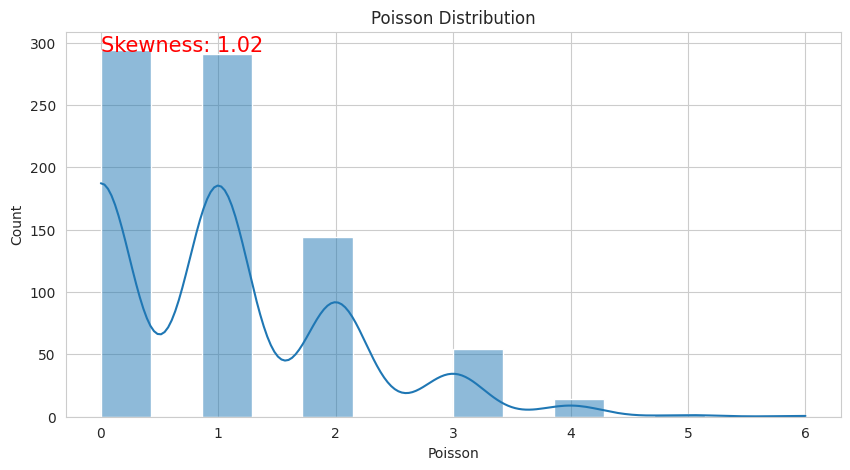

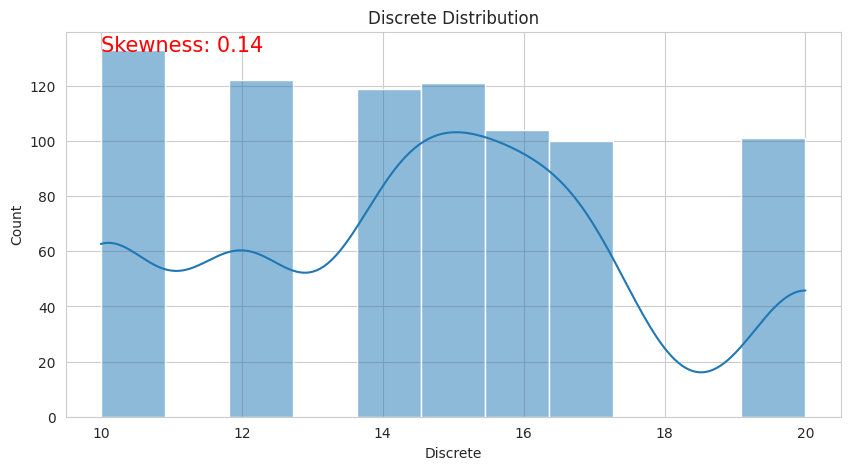

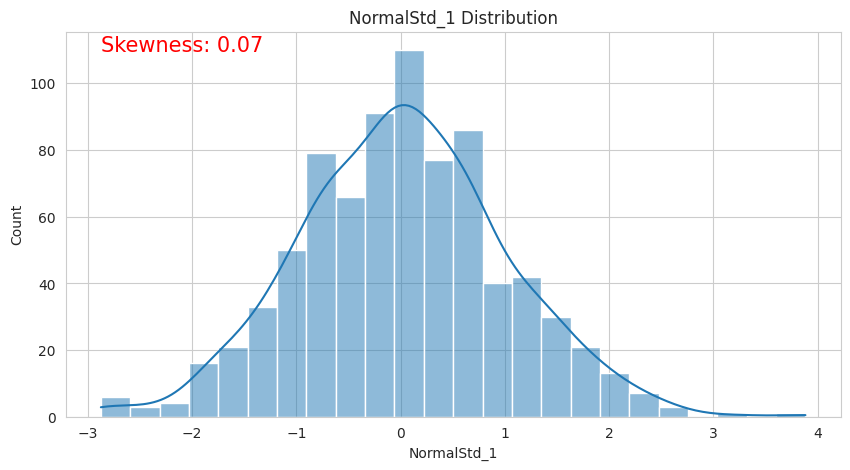

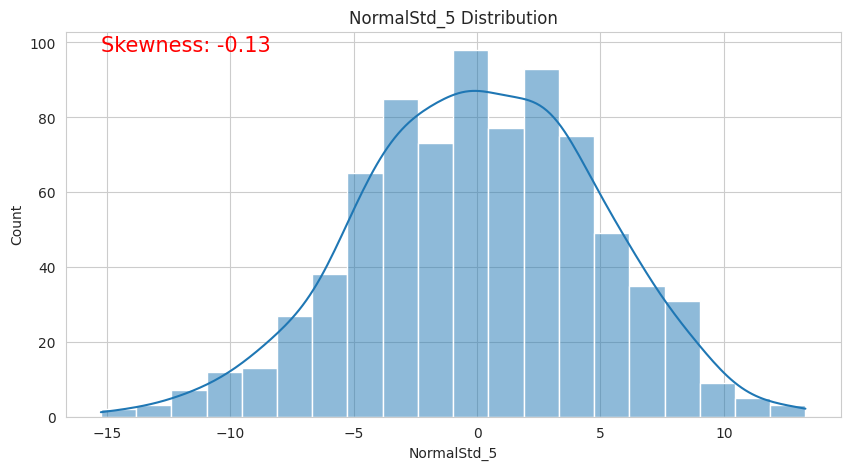

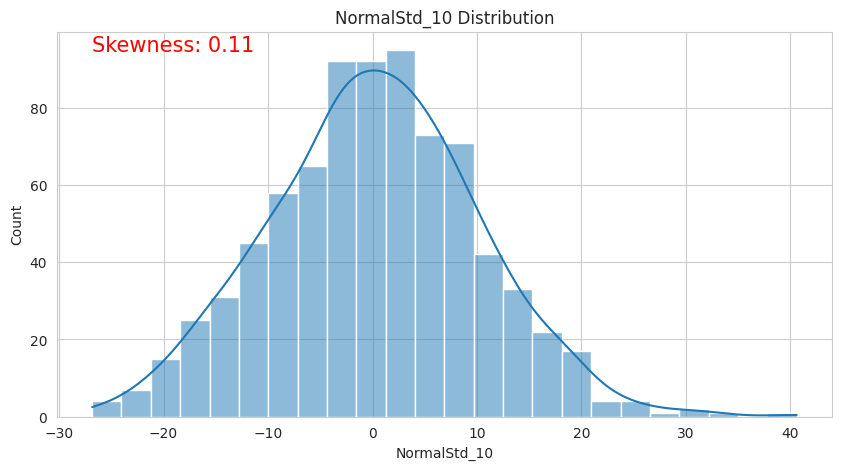

In [12]:
for col in df.columns:
  fig, axes = plt.subplots(figsize=(10,5))
  sns.histplot(data=df, x=col, kde=True)
  plt.title(f"{col} Distribution")
  plt.text(x=df[col].min(), y=axes.get_ylim()[1] * 0.95, s=f"Skewness: {df[col].skew().round(2)}", fontsize=15, c='r')
  plt.show()
  print("\n")

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Kurtosis

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Kurtosis relates to studying the **tails of the distribution**. 
  * It is a measure of outliers in the distribution 
  * A distribution with high kurtosis tends to have significant tails or many outliers 
  * On the other hand, a distribution with low kurtosis tends to have a light tail or few outliers

* An outlier is a value that is not statistically part of the distribution. An outlier can be something that is very unlikely but also might indicate a mismeasure or other error





To calculate kurtosis in your DataFrame or Series, use `.kurtosis()`. The documentation is [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.kurtosis.html)

In [13]:
df.kurtosis()

Normal            -0.134462
Positive Skewed    1.041101
Negative Skewed    0.283836
Exponential        4.065457
Uniform           -1.230196
Bimodal           -1.830466
Multimodal        -1.282046
Poisson            1.029801
Discrete          -0.747910
NormalStd_1        0.250878
NormalStd_5       -0.118906
NormalStd_10       0.165375
dtype: float64

Compare the shape and kurtosis levels for your dataset variables. Can you correlate the kurtosis levels and the distribution shape?

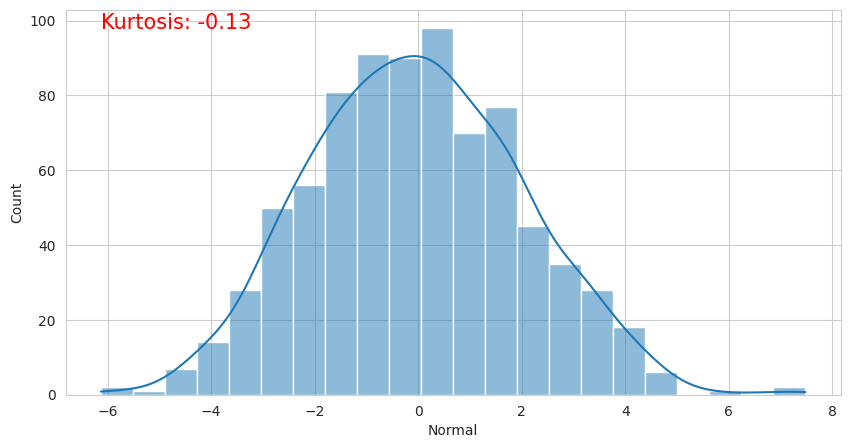

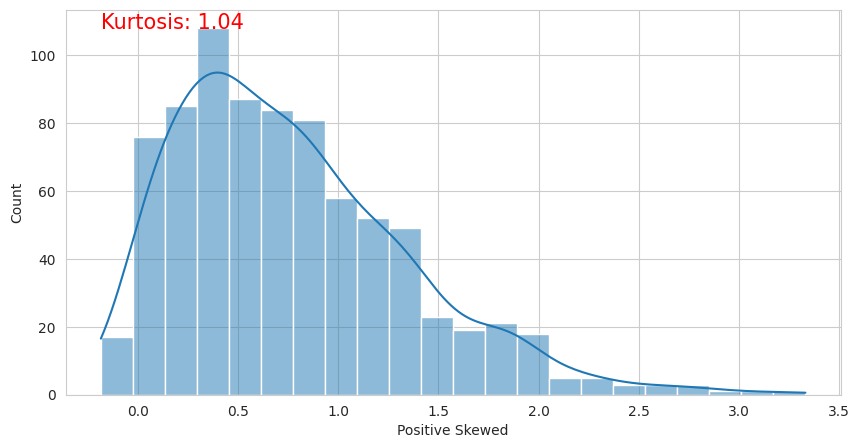

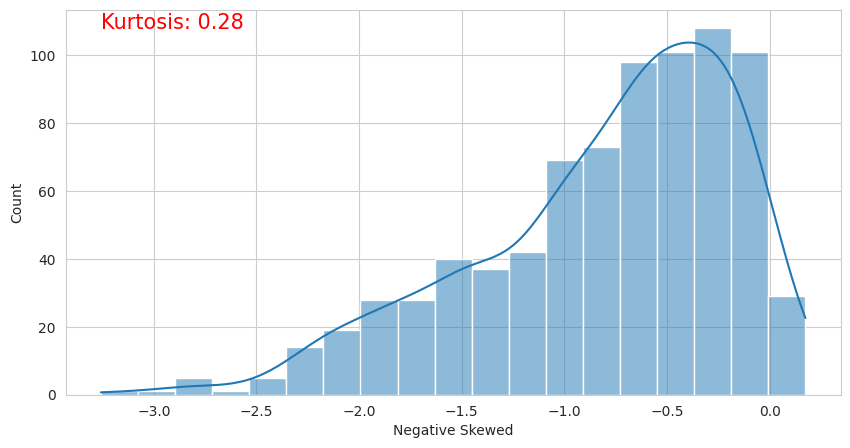

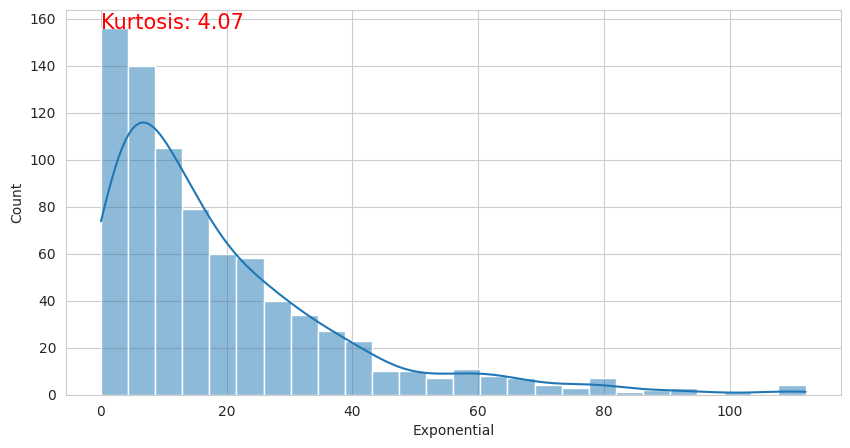

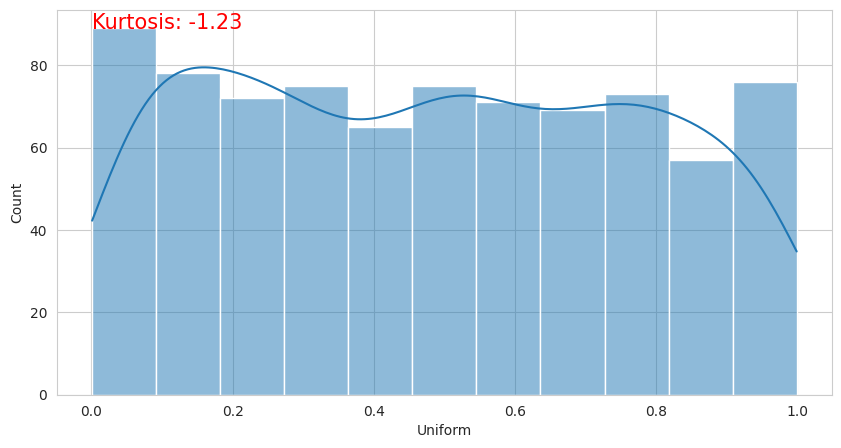

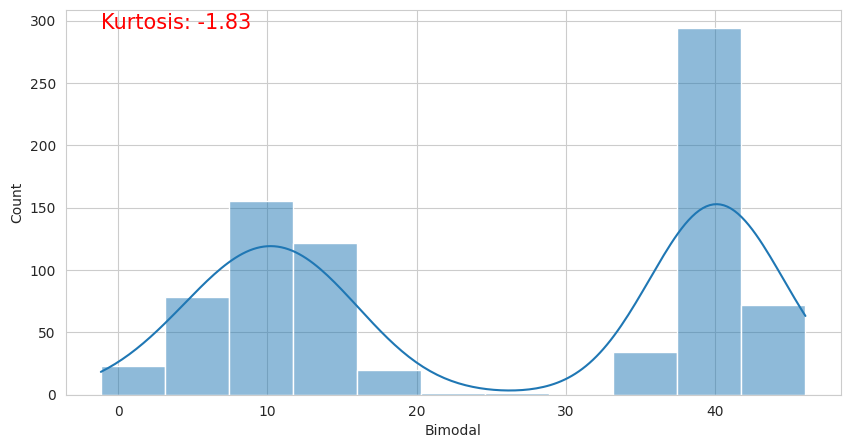

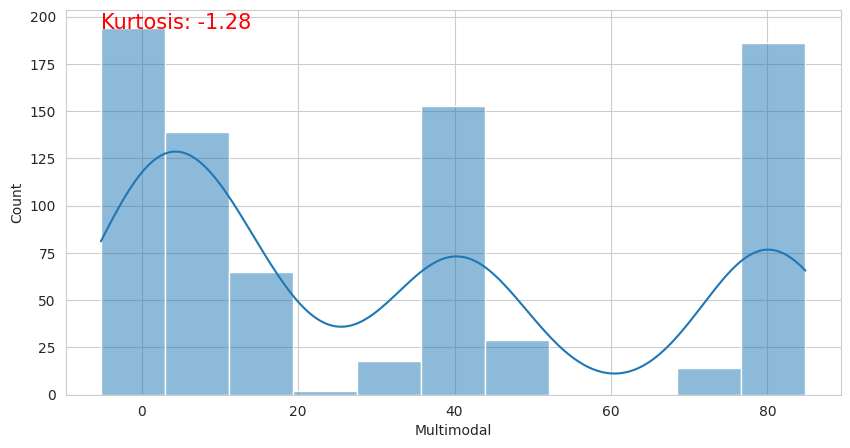

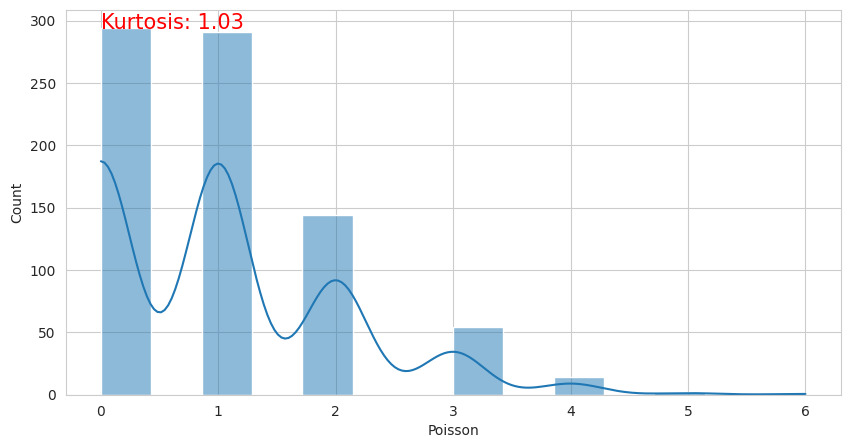

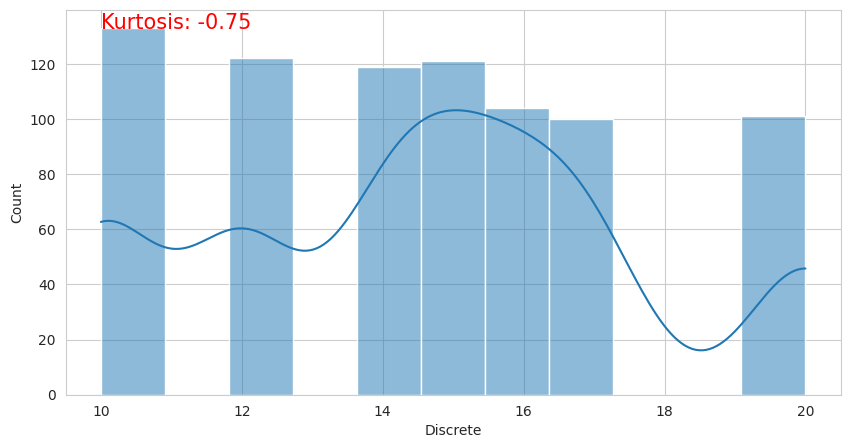

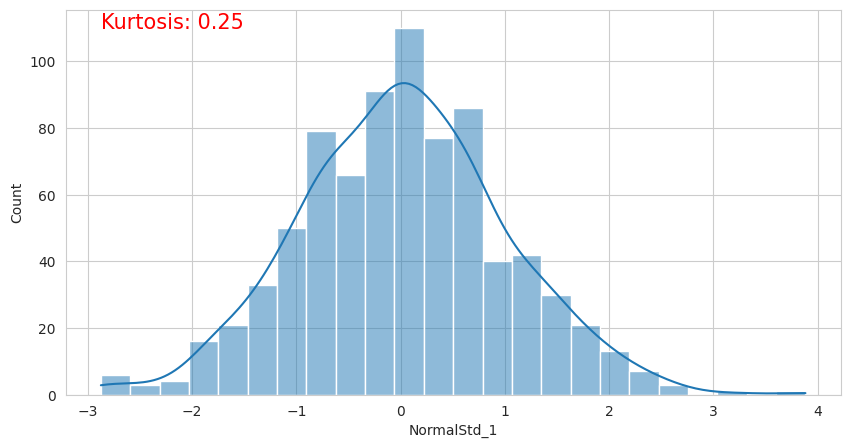

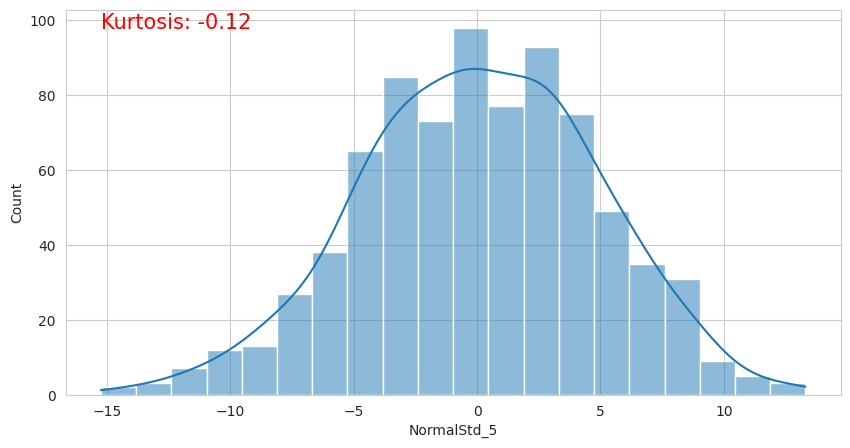

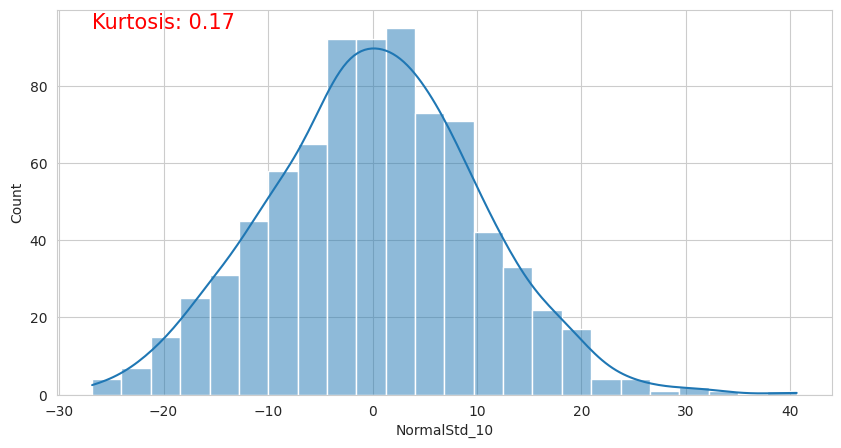

In [14]:
for col in df.columns:
  fig, axes = plt.subplots(figsize=(10,5))
  sns.histplot(data=df, x=col, kde=True)
  plt.text(x=df[col].min(), y=axes.get_ylim()[1] * 0.95, s=f"Kurtosis: {df[col].kurtosis().round(2)}", fontsize=15, c='r')
  plt.show()

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Percentiles and Quartiles

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

A Percentile is **all values below the given percentage**. 
* Let's use some examples so you can better understand:
    * For example, the 50th percentile is all values below which 50% of the observations may be found. For example, if I tell you that your age is at the 50% percentile of your family, that means 50% of your family is younger than you
    * In Data Analytics, we tend to work with **quartiles**, which are the percentiles divided into four parts. Therefore we have:
      * First quartile (Q1 or 25th percentile)
      * Second quartile (Q2 or 50th percentile or median) and 
      * Third quartile (Q3 or 75th percentile)
    * The interquartile range (IQR) is the difference between the first and third quartile. 
      * This is useful in understanding the range where 50% of the most frequent data is.

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

To calculate quartiles in your DataFrame or Series, use `.quantile()`. The documentation is [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.quantile.html)
  * A quartile is a quantile where the sorted data is split into four equal parts. A quartile is the most commonly used quantile. 
  * The argument is `q`, and accepts values between 0 and 1, which are the quantile to compute
  * In the example below, we parse a list with
    * 0: 0 percentile, in other other words, the min value
    * 0.25: 1st quartile, or the value that 25% of data is below
    * 0.50: 2nd quartile, or the value that 50% of data is below. Also known as the median.
    * 0.75: 3rd quartile, or the value that 75% of data is below
    * 1.00: 100 percentile, or the max value

In [15]:
df.quantile(q=[0,0.25,0.50,0.75,1])

,Normal,Positive Skewed,Negative Skewed,Exponential,Uniform,Bimodal,Multimodal,Poisson,Discrete,NormalStd_1,NormalStd_5,NormalStd_10
0.00,-6.12800,-0.18300,-3.2580,0.0390,0.00100,-1.16400,-5.20100,0.0,10.0,-2.874559,-15.249648,-26.837837
0.25,-1.50650,0.32900,-1.1695,5.5970,0.22025,10.01150,3.32525,0.0,12.0,-0.649605,-3.162660,-6.438641
0.50,-0.07600,0.67650,-0.6535,12.9335,0.48450,30.12400,24.02350,1.0,15.0,0.007958,0.097271,0.135175
0.75,1.41975,1.09725,-0.3080,25.9745,0.73500,40.08475,55.71025,2.0,17.0,0.657305,3.468861,6.817045
1.00,7.48000,3.33100,0.1740,112.0070,0.99900,46.06200,84.84900,6.0,20.0,3.882189,13.307091,40.603295


---

Let's check that in practical terms in a graph. Please note the following figures we saw in the previous table for a normal distribution
  * **median**
  * **range**: area delimited by Min and Max
  * **IQR**: area delimited by 1Q and 3Q - This is useful in understanding the area where the 50% most frequent of the data is.

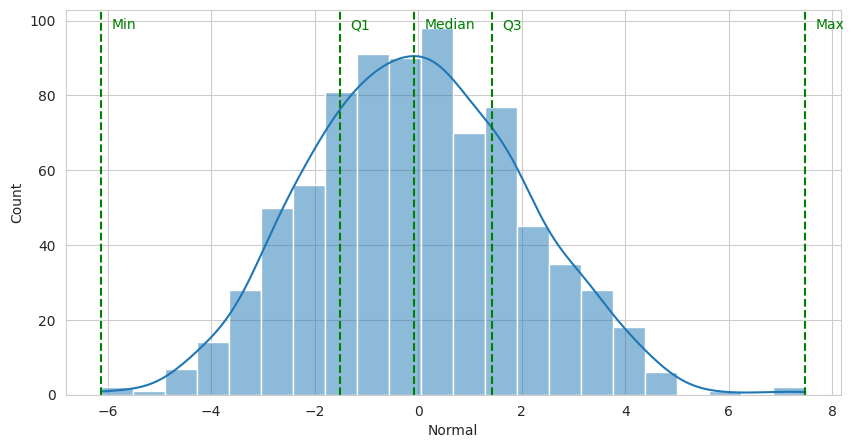

In [16]:
col = 'Normal'
map = pd.Series(data=["Min","Q1","Median","Q3","Max"], index=[0,0.25,0.50,0.75,1])

fig, axes = plt.subplots(figsize=(10,5))
sns.histplot(data=df, x=col, kde=True)
for quantile in [0, 0.25, 0.5, 0.75, 1]:
  plt.axvline(df[col].quantile(q=quantile), color='g', linestyle='dashed', linewidth=1.5)
  plt.text(x=df[col].quantile(q=quantile) + df[col].std()/10,
           y=axes.get_ylim()[1] * 0.95,
           s=f"{map[quantile]}", fontsize=10, c='g')

plt.show()

Let's scan over the variables and pay attention to the same figures (min, max, Q1, Q3, IQR, and Median)

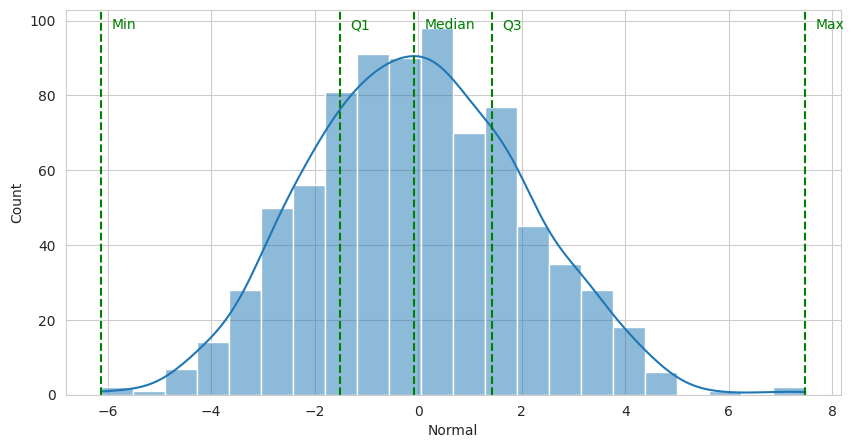

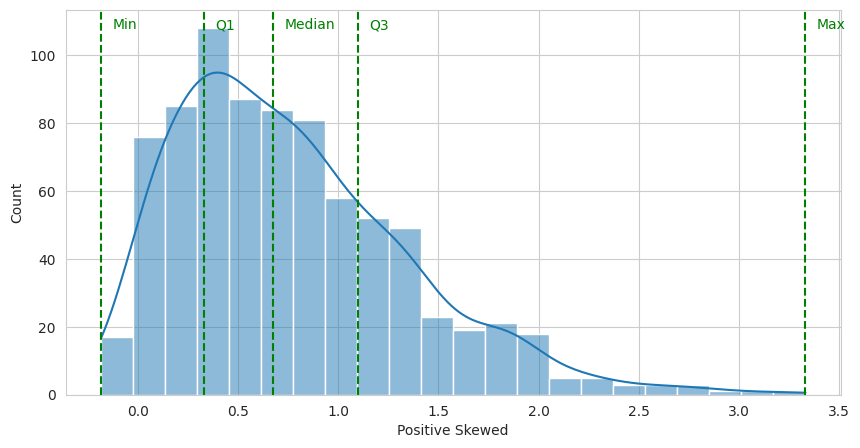

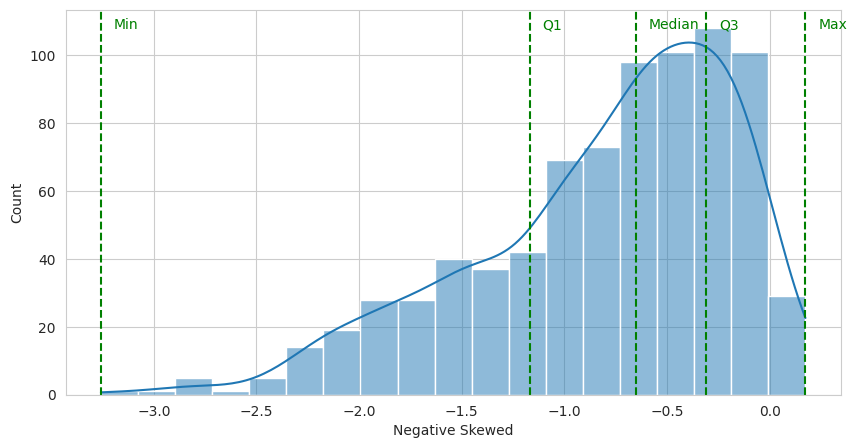

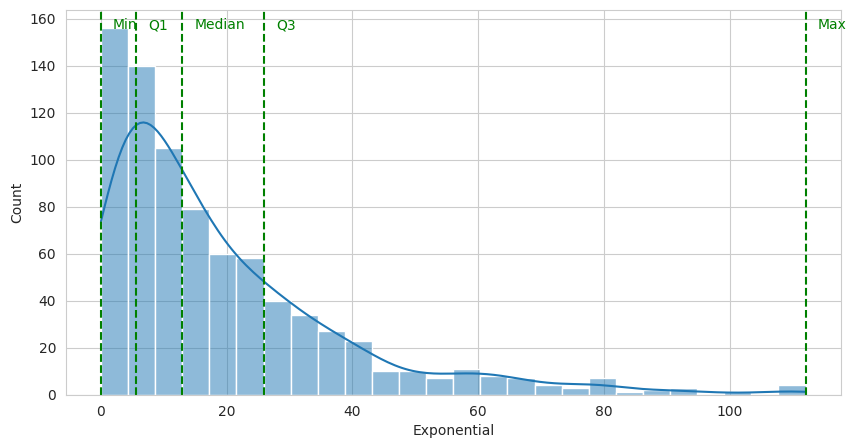

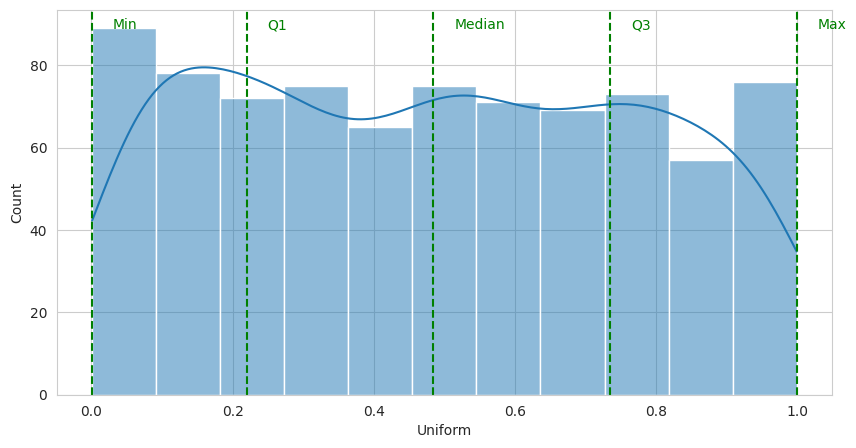

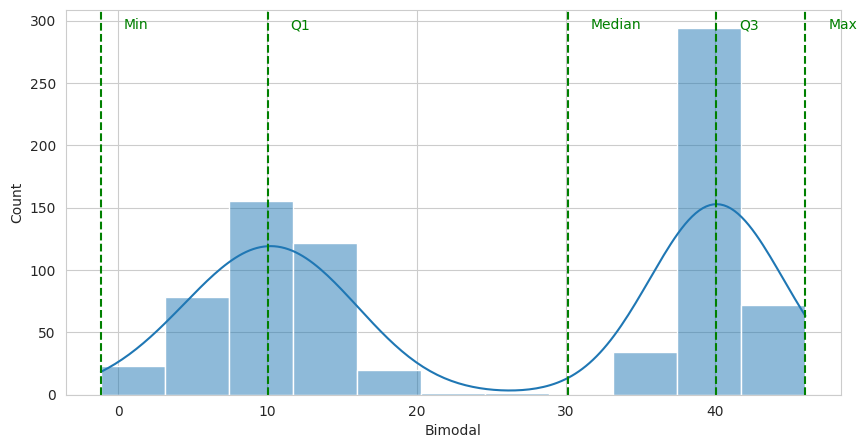

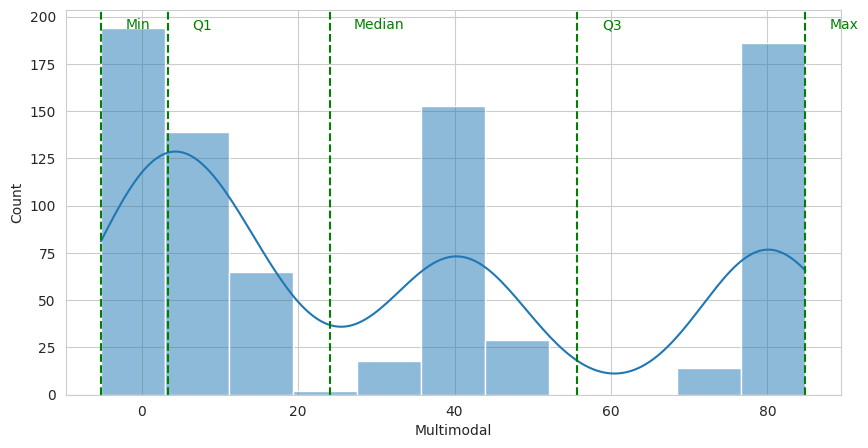

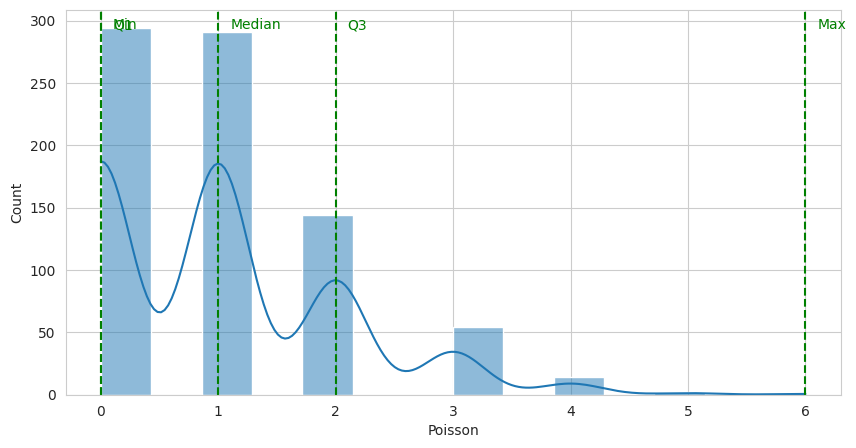

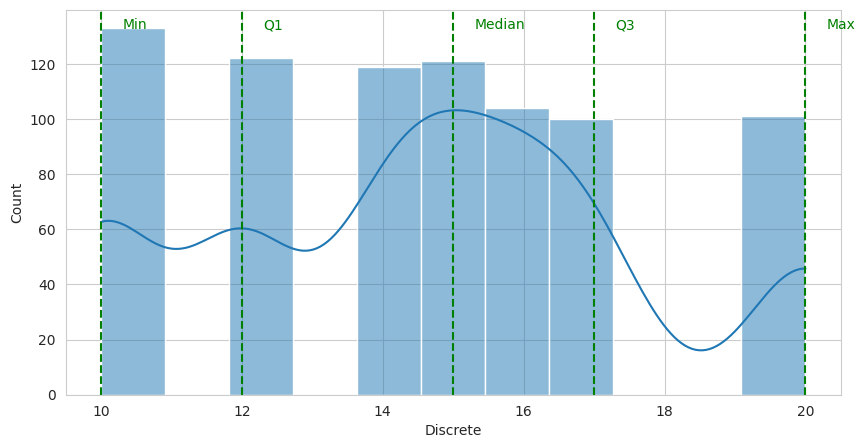

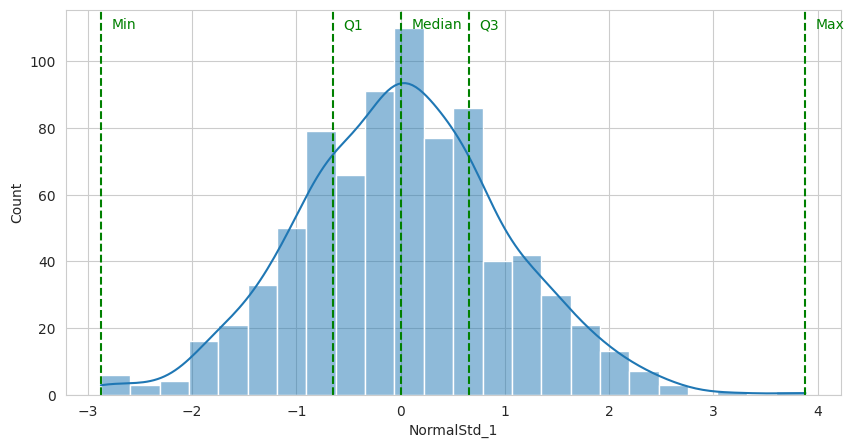

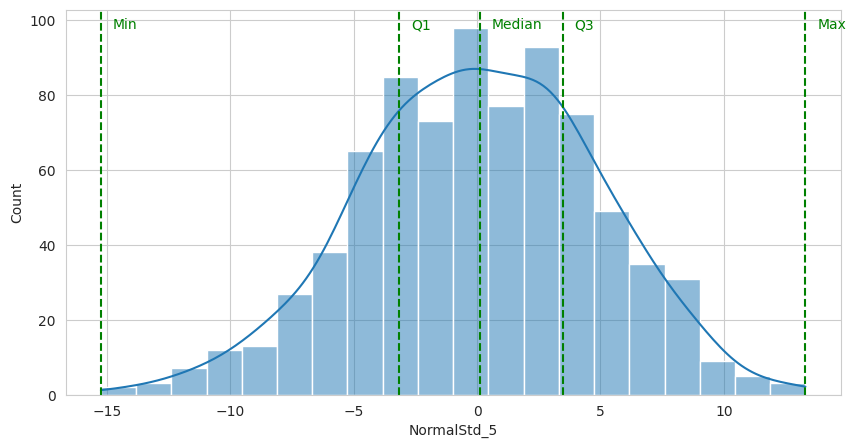

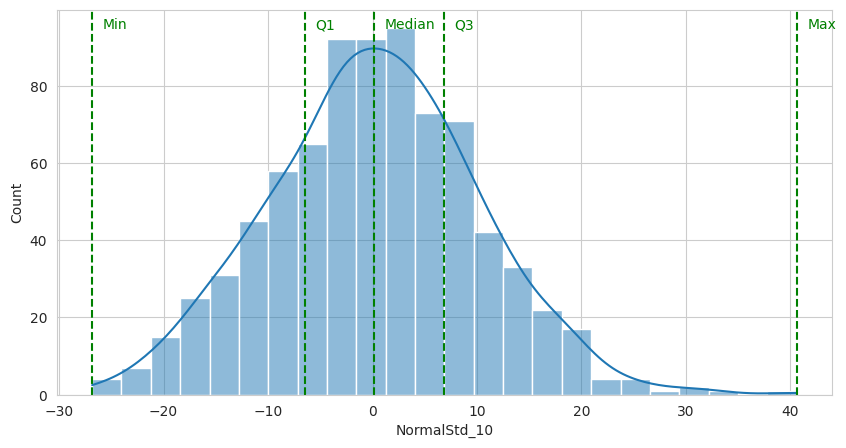

In [17]:
map = pd.Series(data=["Min","Q1","Median","Q3","Max"], index=[0,0.25,0.50,0.75,1])

for col in df.columns:
  fig, axes = plt.subplots(figsize=(10,5))
  sns.histplot(data=df, x=col, kde=True)
  for quantile in [0, 0.25, 0.5, 0.75, 1]:
    plt.axvline(df[col].quantile(q=quantile), color='g', linestyle='dashed', linewidth=1.5)
    plt.text(x=df[col].quantile(q=quantile) + df[col].std()/10, y=axes.get_ylim()[1] * 0.95, s=f"{map[quantile]}", fontsize=10, c='g')
    

  plt.show()

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

#### QQ Plot

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

We are interested in assessing how close our data is to a normal distribution. For that, we use a QQ Plot (Quantile-Quantile plot)
  * When the quantiles of two variables are plotted against each other, then the plot obtained is known as a QQ plot. 
  * This plot provides a summary of **whether the distributions of two variables are similar or not with respect to the locations.**


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

If we **compare** our **data** to a **normal distribution**, we are assessing if our data is normally distributed, then:
* If your data has the profile of a normal distribution, it should roughly fall in a straight line

  * Since this is a visual tool for comparison, results can also be quite subjective but nonetheless useful in the underlying understanding distribution of a variable(s).
  * It is particularly useful in identifying a subtle bimodal or multimodal distribution that would not be visible from a gaussian plot. 

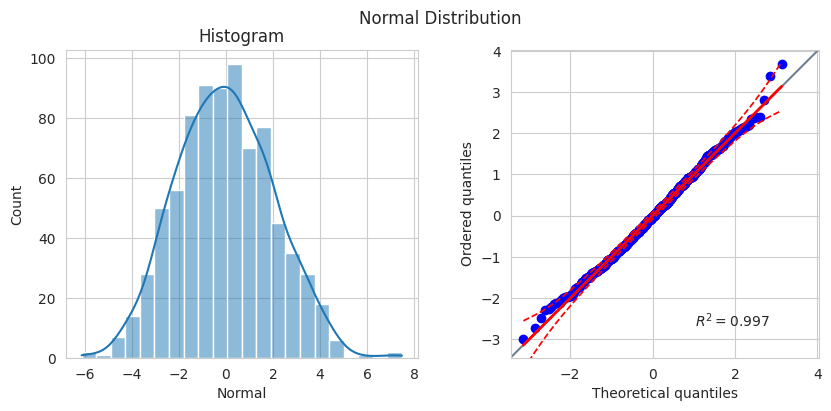

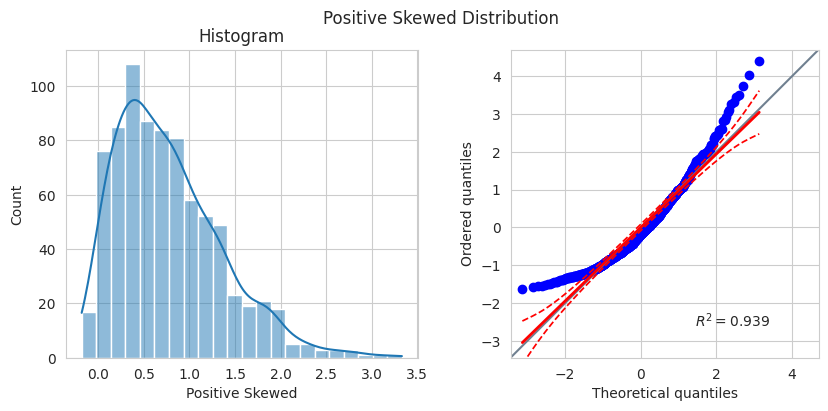

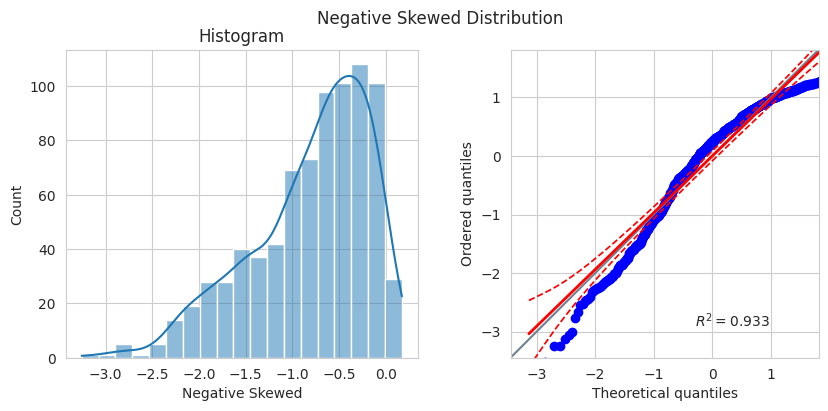

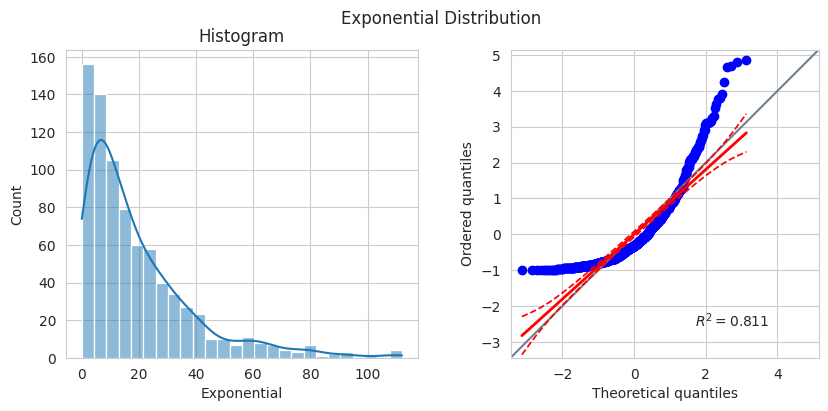

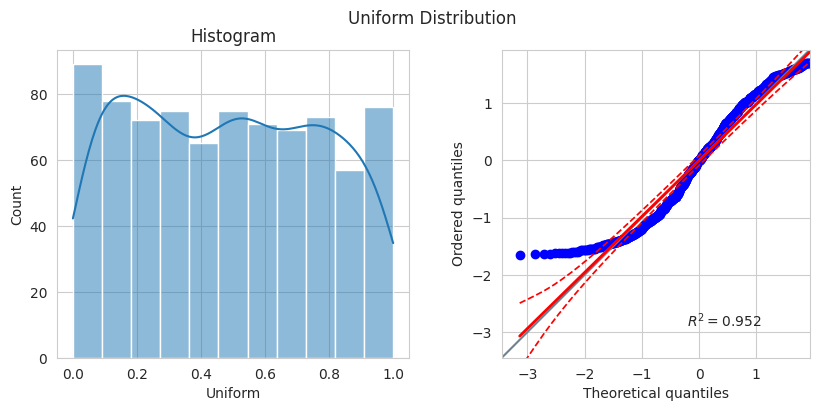

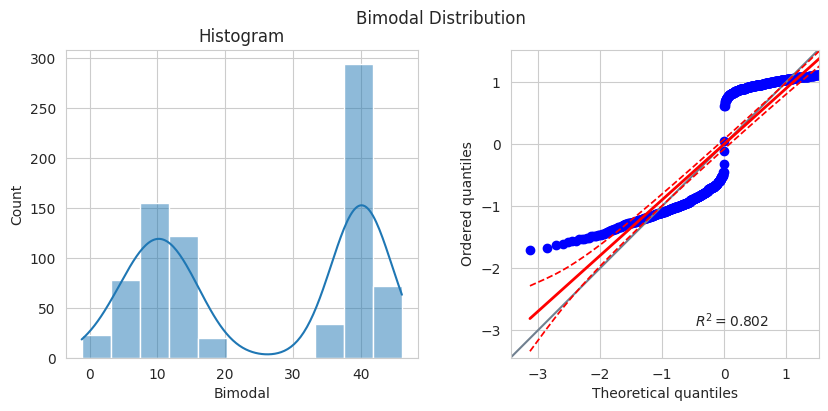

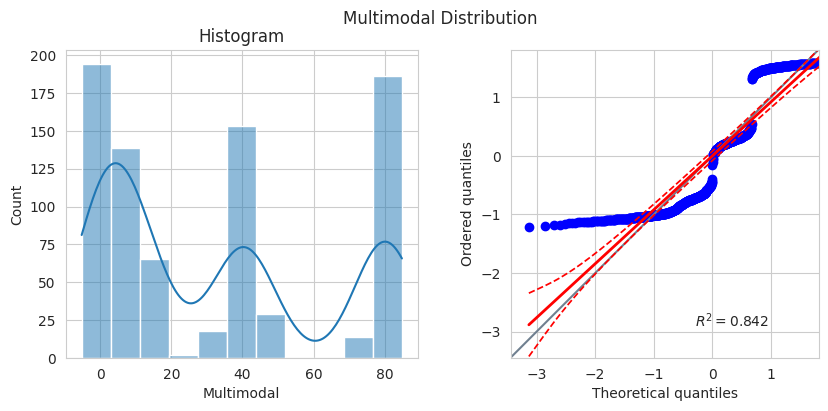

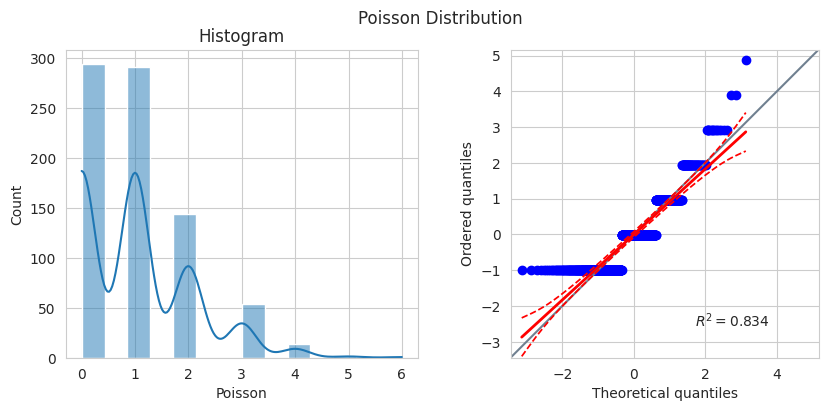

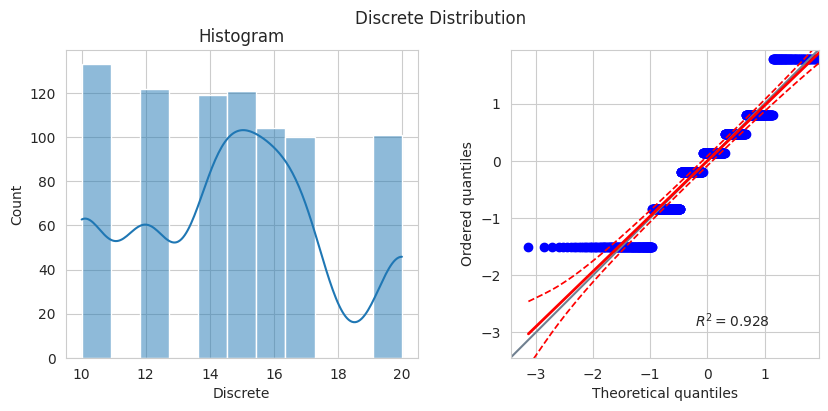

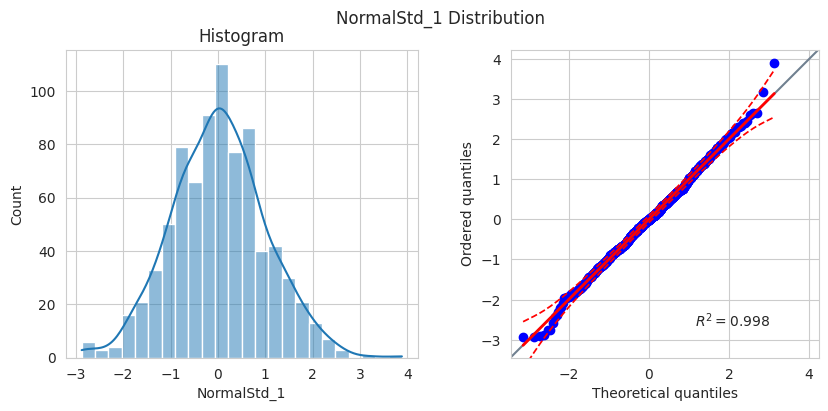

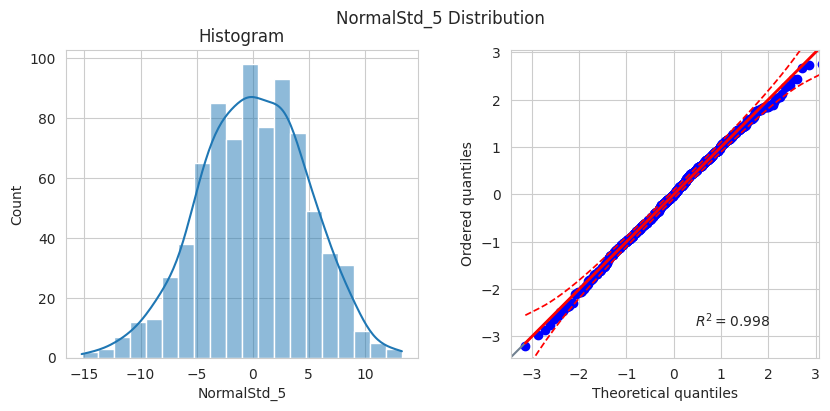

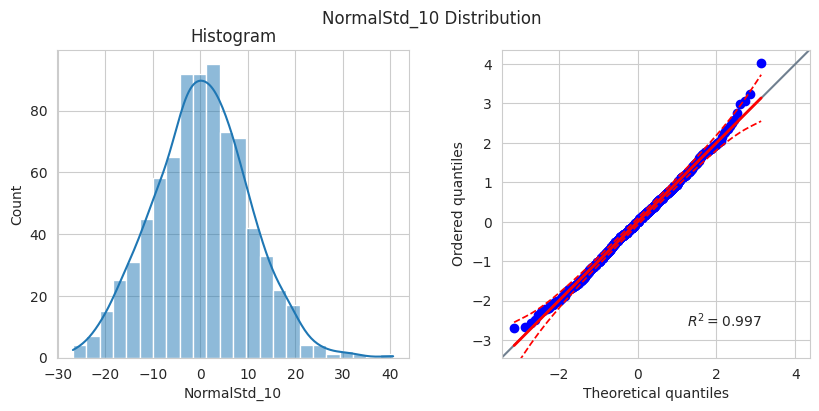

In [18]:
import numpy as np
import pingouin as pg
for col in df.columns:
  fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(10,4))
  sns.histplot(data=df, x=col, kde=True,ax=axes[0])
  axes[0].set_title("Histogram")
  pg.qqplot(df[col], dist='norm',ax=axes[1])
  fig.suptitle(f"{col} Distribution")
  plt.show()
  print("\n")

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Range

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Range is  the difference between the **maximum and minimum** values of your distribution


You can calculate the minimum values of your numerical data with `.min()`. The documentation link is [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.min.html)

In [19]:
df.min()

Normal             -6.128000
Positive Skewed    -0.183000
Negative Skewed    -3.258000
Exponential         0.039000
Uniform             0.001000
Bimodal            -1.164000
Multimodal         -5.201000
Poisson             0.000000
Discrete           10.000000
NormalStd_1        -2.874559
NormalStd_5       -15.249648
NormalStd_10      -26.837837
dtype: float64

You can calculate the max values of your numerical data with `.max()`. The documentation link is [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.max.html)

In [20]:
df.max()

Normal               7.480000
Positive Skewed      3.331000
Negative Skewed      0.174000
Exponential        112.007000
Uniform              0.999000
Bimodal             46.062000
Multimodal          84.849000
Poisson              6.000000
Discrete            20.000000
NormalStd_1          3.882189
NormalStd_5         13.307091
NormalStd_10        40.603295
dtype: float64

The range of the data is the difference between max and min

In [21]:
df.max() - df.min()

Normal              13.608000
Positive Skewed      3.514000
Negative Skewed      3.432000
Exponential        111.968000
Uniform              0.998000
Bimodal             47.226000
Multimodal          90.050000
Poisson              6.000000
Discrete            10.000000
NormalStd_1          6.756748
NormalStd_5         28.556739
NormalStd_10        67.441133
dtype: float64

Let's plot the data and check its range

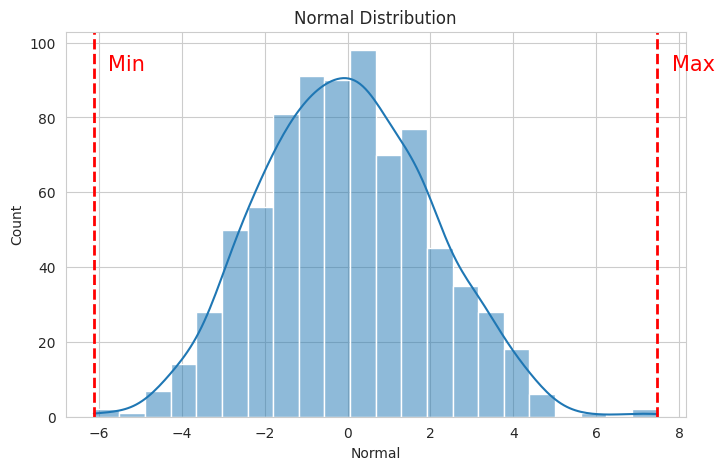

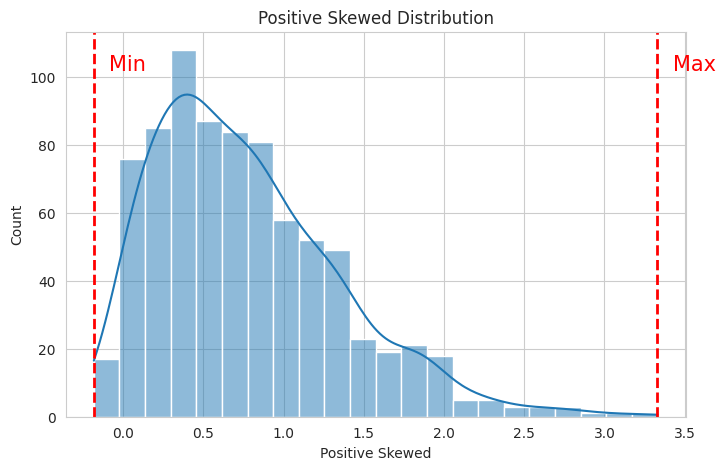

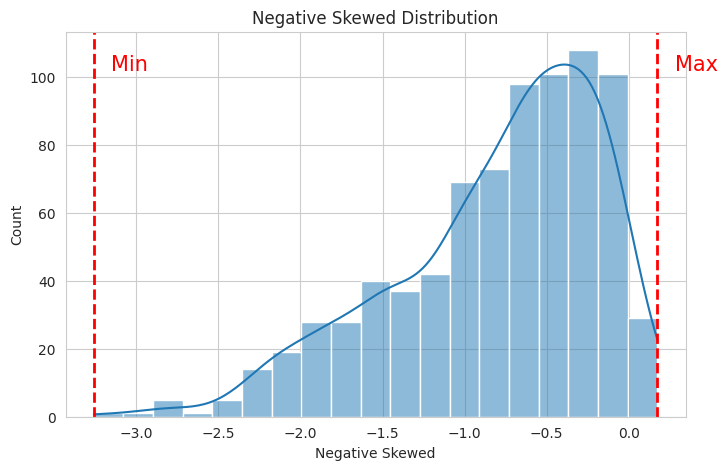

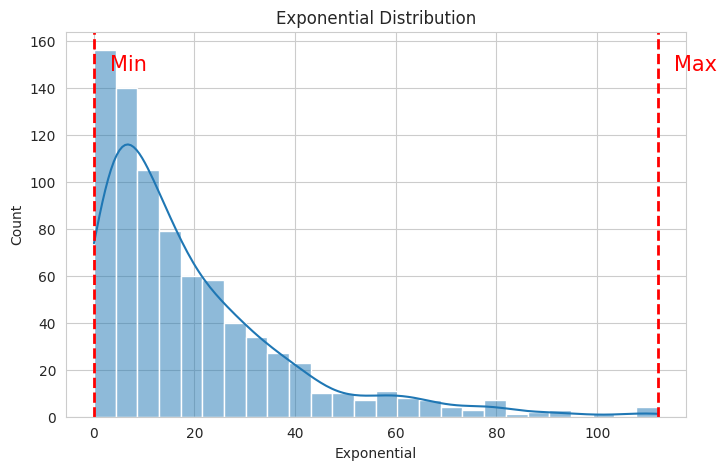

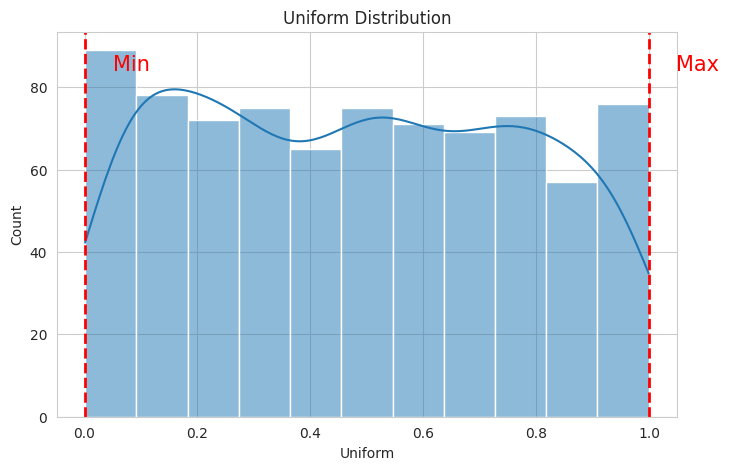

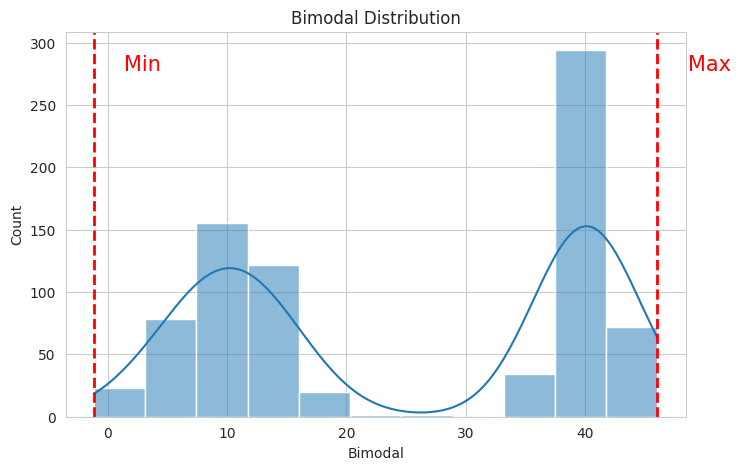

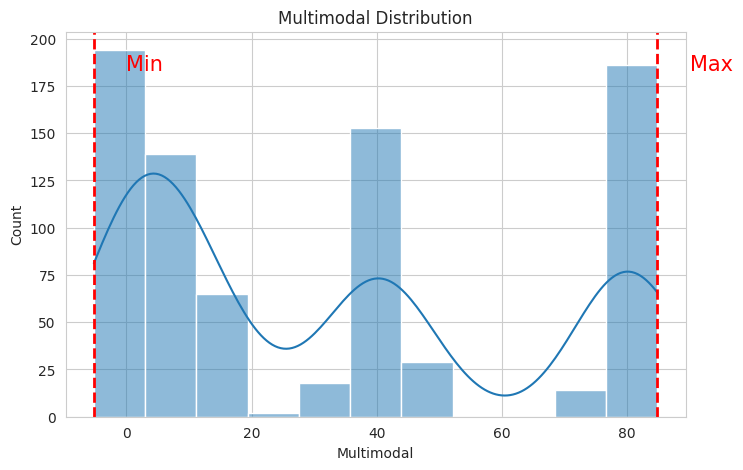

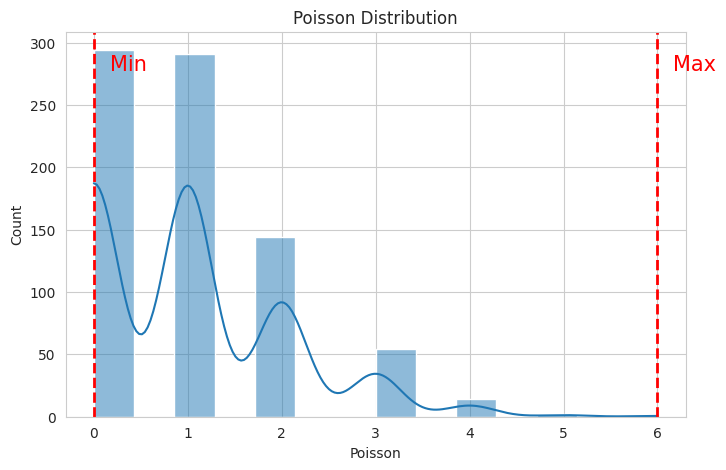

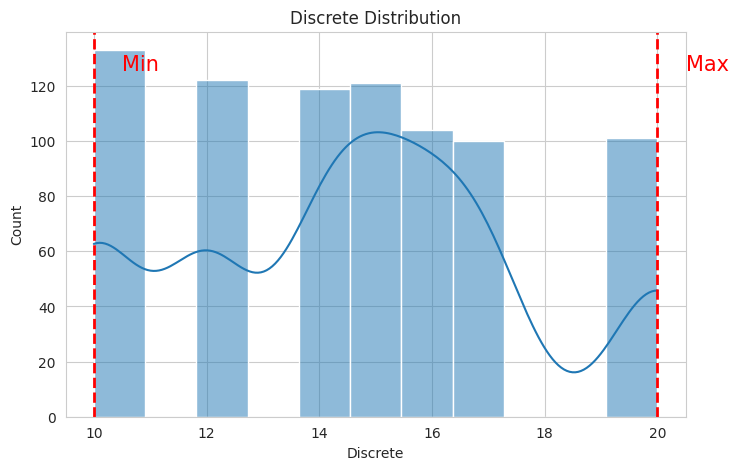

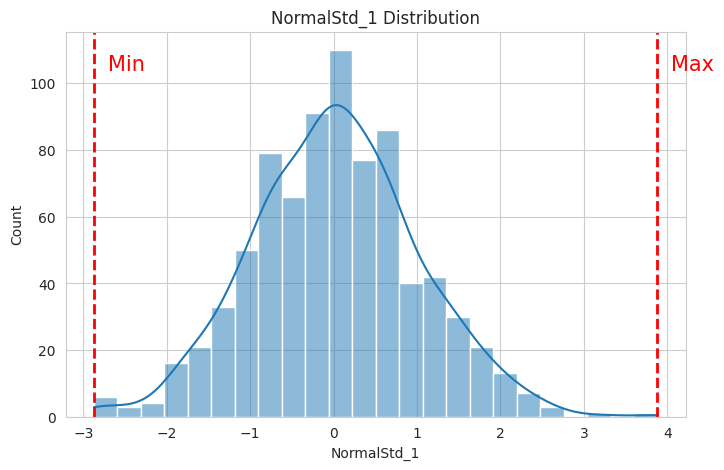

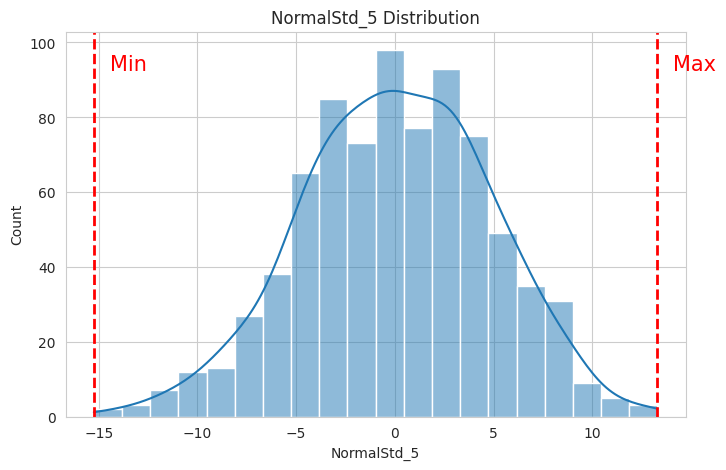

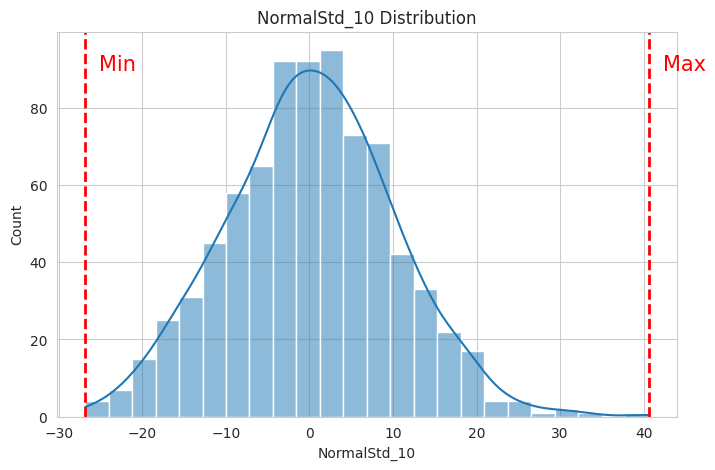

In [22]:
for col in df.columns:
    
  fig, axes = plt.subplots(figsize=(8,5))
  plt.title(f"{col} Distribution")
  sns.histplot(data=df, x=col, kde=True)

  plt.axvline(df[col].min(), color='r', linestyle='dashed', linewidth=2)
  plt.text(x=df[col].min() + df[col].std()/6 , y=axes.get_ylim()[1] * 0.90, s='Min', fontsize=15, c='r')

  plt.axvline(df[col].max(), color='r', linestyle='dashed', linewidth=2)
  plt.text(x=df[col].max() + df[col].std()/6 , y=axes.get_ylim()[1] * 0.9, s='Max', fontsize=15, c='r')

  plt.show()
  print("\n")